# CS 703 - Applied Data Science Project
## Final Combined Project Notebook
### Sentiment Analysis of Amazon Product Reviews Using Natural Language Processing

| Item | Submission Detail |
|---|---|
| **Student** | Nawaz Shareef Mohammed |
| **Course** | CS 703 - Applied Data Science Project |
| **Final Task** | Task 6.3 - Final Report and Reproducible Code |
| **Primary dataset file** | `C:\CS703\Reviews.csv` |
| **Notebook file** | `C:\CS703\CS703_Final_Combined_Project_Revised.ipynb` |


## Table of Contents

1. [Instructor Feedback Integration and Final Corrections](#instructor-feedback-integration-and-final-corrections)  
2. [Submission Access and Required File Structure](#submission-access-and-required-file-structure)  
3. [Project Configuration and Environment](#project-configuration-and-environment)  
4. [Phase 1.0 - Business Understanding](#phase-10--business-understanding)  
5. [Phase 2.0 - Data Understanding](#phase-20--data-understanding)  
6. [Phase 3.0 - Data Preparation](#phase-30--data-preparation)  
7. [Phase 4.0 - Modeling](#phase-40--modeling)  
8. [Phase 5.0 - Evaluation](#phase-50--evaluation)  
9. [Phase 6.0 - Deployment Planning and Project Review](#phase-60--deployment-planning-and-project-review)  
10. [Final Conclusions and Project Status](#final-conclusions-and-project-status)  
11. [Final Submission Checklist](#final-submission-checklist)


## Instructor Feedback Integration and Final Corrections

The final notebook incorporates the grading instructions and previously documented feedback rather than merely combining earlier files.

| Instructor requirement or comment | Correction made in this final notebook | Verification location |
|---|---|---|
| Code must use **one path** and run when code and datasets are placed together. | Removed Kaggle, Colab, recursive-search, Desktop, and current-folder fallbacks. All input and output paths originate from `C:\CS703\`. | Project Configuration cell |
| The code and datasets must be accessible without a special ID or password. | The submission checklist requires `Reviews.csv` to be submitted directly beside the notebook. A public source is documented only for provenance. | Submission Access section and README |
| Do not explain what a chart type is; explain what its results mean to the business problem. | Added a business interpretation directly after each major EDA and model-evaluation figure. | Phases 2 and 4 |
| Samples should show actual deliverable content, not generic descriptions. | Tables, metrics, figures, cleaning logs, split counts, model outputs, and deployment artifacts are generated by executable cells. | All CRISP-DM phases |
| Maintain consistent dates and documentation. | Phase dates, task names, completion status, limitations, and final decisions are presented consistently. | Phase introductions and final status |
| Every final claim must distinguish completed work from planned work. | BERT, GloVe/LSTM, SHAP, full-corpus training, ordinal rating prediction, and a live endpoint are explicitly labeled incomplete when not demonstrated. | Phases 5-6 and Final Status |


## Submission Access and Required File Structure

Submit the following files together. The assessor should not need to create a Kaggle account, request access, or enter credentials.

```text
C:\CS703\
|-- CS703_Final_Combined_Project_Revised.ipynb
|-- Reviews.csv
|-- README.txt
|-- requirements.txt
|-- outputs\                 # created automatically
`-- model_artifacts\         # created automatically
```

**Dataset provenance:** Amazon Fine Food Reviews, Stanford SNAP / Kaggle SNAP. The public Stanford project page is `https://snap.stanford.edu/data/web-FineFoods.html`. The exact `Reviews.csv` used in this project should still be submitted directly because the Stanford page distributes a differently formatted raw text file, while the notebook expects the CSV schema verified below.


## Project Configuration and Environment

### Environment Setup

Before opening the notebook, install the packages listed in `C:\CS703\requirements.txt`:

```bat
py -m pip install -r C:\CS703\requirements.txt
```

The text-normalization step attempts to use `spaCy` and `en_core_web_sm` when available. If that optional language model is not installed, the notebook automatically uses a deterministic token-cleaning fallback and continues without downloading anything.


In [1]:
from pathlib import Path
import os
import re
import string
import warnings
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score
)
import joblib

try:
    import spacy
except ImportError:
    spacy = None

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
WORKING_SAMPLE_SIZE = 50_000
CONFIDENCE_THRESHOLD = 0.65

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
NAVY = '#1F3864'
BLUE = '#2E5F8A'
LIGHT = '#D5E8F0'
GOLD = '#E5A118'
COLORS = [NAVY, BLUE, LIGHT]


In [ ]:
import shutil
import subprocess
import sys
import zipfile

import pandas as pd
from pandas.errors import ParserError


BASE_DIR = Path(r"C:\CS703")
DATA_PATH = BASE_DIR / "Reviews.csv"
PROCESSED_DATA_PATH = BASE_DIR / "phase3_final_dataset.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "model_artifacts"
DOWNLOAD_DIR = BASE_DIR / "_kaggle_download"

KAGGLE_DATASET = "snap/amazon-fine-food-reviews"
KAGGLE_FILE = "Reviews.csv"

REQUIRED_COLUMNS = {"Score", "Text"}

BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def detect_csv_encoding(csv_path):
    """
    Return a working text encoding when the file is a valid Amazon
    Reviews CSV. Return None when the file is missing, compressed,
    binary, corrupted, or has the wrong schema.
    """

    csv_path = Path(csv_path)

    if not csv_path.exists() or csv_path.stat().st_size == 0:
        return None

    # A ZIP archive should not be read directly with pandas.
    if zipfile.is_zipfile(csv_path):
        return None

    # Detect obviously binary content.
    with csv_path.open("rb") as file:
        first_bytes = file.read(4096)

    if b"\x00" in first_bytes:
        return None

    possible_encodings = [
        "utf-8-sig",
        "utf-8",
        "cp1252",
        "latin-1",
    ]

    for encoding in possible_encodings:
        try:
            sample = pd.read_csv(
                csv_path,
                nrows=5,
                encoding=encoding,
                on_bad_lines="error",
            )

            if REQUIRED_COLUMNS.issubset(sample.columns):
                return encoding

        except (UnicodeDecodeError, ParserError, ValueError):
            continue

    return None

# CHECK THE CURRENT FILE

detected_encoding = detect_csv_encoding(DATA_PATH)

if detected_encoding is None:

    if DATA_PATH.exists():
        print(
            "The existing Reviews.csv is invalid, corrupted, compressed, "
            "or has the wrong schema."
        )
        print("Removing the invalid file before downloading a fresh copy.")
        DATA_PATH.unlink()

    # Remove an incomplete prior download directory.
    if DOWNLOAD_DIR.exists():
        shutil.rmtree(DOWNLOAD_DIR)

    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

    print("Downloading a fresh Reviews.csv file from Kaggle...")

    # Install or update kagglehub.
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--quiet",
            "kagglehub",
        ]
    )

    import kagglehub

    try:
        downloaded_location = Path(
            kagglehub.dataset_download(
                KAGGLE_DATASET,
                path=KAGGLE_FILE,
                output_dir=str(DOWNLOAD_DIR),
                force_download=True,
            )
        )

        print(f"Kaggle returned: {downloaded_location}")

        candidates = []

        # The returned location may be the file itself.
        if downloaded_location.exists() and downloaded_location.is_file():
            candidates.append(downloaded_location)

        # It may instead be a folder containing the file.
        if downloaded_location.exists() and downloaded_location.is_dir():
            candidates.extend(
                downloaded_location.rglob(KAGGLE_FILE)
            )

        # Search only the dedicated download folder.
        candidates.extend(DOWNLOAD_DIR.rglob(KAGGLE_FILE))

        # Remove duplicate candidate paths.
        candidates = list(
            dict.fromkeys(
                candidate.resolve()
                for candidate in candidates
                if candidate.exists() and candidate.is_file()
            )
        )

        zip_candidates = [
            file
            for file in DOWNLOAD_DIR.rglob("*")
            if file.is_file() and zipfile.is_zipfile(file)
        ]

        for zip_path in zip_candidates:
            extraction_folder = DOWNLOAD_DIR / "extracted"
            extraction_folder.mkdir(parents=True, exist_ok=True)

            print(f"Extracting compressed file: {zip_path.name}")

            with zipfile.ZipFile(zip_path, "r") as archive:
                archive.extractall(extraction_folder)

            candidates.extend(
                extraction_folder.rglob(KAGGLE_FILE)
            )

        candidates = list(
            dict.fromkeys(
                candidate.resolve()
                for candidate in candidates
                if candidate.exists() and candidate.is_file()
            )
        )

        if not candidates:
            raise FileNotFoundError(
                "The Kaggle download finished, but Reviews.csv "
                "could not be found in the download directory."
            )

        # Select the first candidate that has the expected schema.
        selected_file = None
        selected_encoding = None

        for candidate in candidates:
            candidate_encoding = detect_csv_encoding(candidate)

            if candidate_encoding is not None:
                selected_file = candidate
                selected_encoding = candidate_encoding
                break

        if selected_file is None:
            candidate_names = "\n".join(
                f"  - {candidate}" for candidate in candidates
            )

            raise ValueError(
                "Files were downloaded, but none was a valid Amazon "
                "Reviews.csv file with Score and Text columns.\n\n"
                f"Files inspected:\n{candidate_names}"
            )

        shutil.copy2(selected_file, DATA_PATH)

        detected_encoding = detect_csv_encoding(DATA_PATH)

        if detected_encoding is None:
            raise ValueError(
                "Reviews.csv was copied to C:\\CS703, but final validation failed."
            )

        print(f"Dataset successfully saved to: {DATA_PATH}")
        print(f"Detected encoding: {detected_encoding}")

    except Exception as error:
        raise RuntimeError(
            "The Amazon Fine Food Reviews dataset could not be downloaded "
            "or validated.\n\n"
            "Check the internet connection and confirm that Kaggle is "
            "accessible from this computer.\n\n"
            f"Original error: {type(error).__name__}: {error}"
        ) from error


sample_data = pd.read_csv(
    DATA_PATH,
    nrows=5,
    encoding=detected_encoding,
)

missing_columns = REQUIRED_COLUMNS.difference(sample_data.columns)

if missing_columns:
    raise ValueError(
        "The downloaded dataset does not have the expected schema.\n"
        f"Missing columns: {sorted(missing_columns)}\n"
        f"Available columns: {sample_data.columns.tolist()}"
    )

print("\n=== PROJECT PATH VERIFICATION ===")
print(f"Base directory       : {BASE_DIR}")
print(f"Input dataset        : {DATA_PATH}")
print(f"Processed dataset    : {PROCESSED_DATA_PATH}")
print(f"Figure output folder : {OUTPUT_DIR}")
print(f"Model output folder  : {MODEL_DIR}")
print(f"Dataset encoding     : {detected_encoding}")
print(f"Dataset size         : {DATA_PATH.stat().st_size / 1_000_000:.2f} MB")
print(f"Dataset columns      : {sample_data.columns.tolist()}")

The existing Reviews.csv is invalid, corrupted, compressed, or has the wrong schema.
Removing the invalid file before downloading a fresh copy.


100%|██████████| 115M/115M [02:23<00:00, 834kB/s]  


Kaggle returned: C:\CS703\_kaggle_download\Reviews.csv
Extracting compressed file: Reviews.csv
Dataset successfully saved to: C:\CS703\Reviews.csv
Detected encoding: utf-8-sig

=== PROJECT PATH VERIFICATION ===
Base directory       : C:\CS703
Input dataset        : C:\CS703\Reviews.csv
Processed dataset    : C:\CS703\phase3_final_dataset.csv
Figure output folder : C:\CS703\outputs
Model output folder  : C:\CS703\model_artifacts
Dataset encoding     : utf-8-sig
Dataset size         : 300.90 MB
Dataset columns      : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
Kaggle download and dataset validation completed successfully.


# Phase 1.0 – Business Understanding

## Task 1.1 – Determine Business Objectives

### Background and Business Problem
Online retailers receive more product feedback than human teams can read and categorize consistently. Amazon-scale review volumes create a practical need for automated text analysis that can rapidly separate positive, neutral, and negative customer experiences. A reliable classifier can help product, quality, customer-service, and marketing teams identify emerging dissatisfaction, monitor sentiment trends, and prioritize reviews that require human attention.

### Business Goals
1. Automatically classify Amazon product reviews as **Negative**, **Neutral**, or **Positive**.
2. Investigate whether review text can support prediction of the original **1–5 star rating**.
3. Compare a progression of NLP approaches: **TF-IDF**, **word embeddings**, and **BERT**.
4. Determine when the additional cost and complexity of contextual transformer models is justified.
5. Produce a reusable and openly documented NLP workflow.

### Business Success Criteria
- Final three-class model weighted F1 target: **0.88 or higher**.
- A defensible recommendation explaining when TF-IDF is sufficient and when BERT is needed.
- Explainability output for at least **200 test samples**, originally planned with SHAP.
- A reproducible train/validation/test process with no feature leakage.
- A documented deployment and monitoring strategy.

### Constraints and Organizational Impact
The work was completed by one researcher using free or low-cost computing environments. GPU sessions, semester deadlines, class imbalance, and the time required to normalize a large text corpus constrained the scope. The intended organizational benefit is faster and more consistent review triage; the main risk is over-reliance on predictions for the ambiguous Neutral class.


## Task 1.2 – Assess the Situation

### Resource Inventory

| Resource | Project Use |
|---|---|
| Amazon Fine Food Reviews dataset | Primary corpus for EDA, preparation, and modeling |
| Amazon Customer Reviews dataset | Proposed secondary source for future cross-domain testing |
| Google Colab and Kaggle Notebooks | CPU/GPU execution environments |
| Python, pandas, NumPy | Data manipulation and numerical analysis |
| BeautifulSoup, spaCy | HTML removal and text normalization |
| scikit-learn | TF-IDF features, splitting, models, and evaluation |
| Hugging Face / PyTorch | Planned BERT tier |
| SHAP | Planned explainability analysis |
| GitHub | Planned source-code and artifact publication |

### Requirements, Assumptions, and Constraints
- Ratings are mapped as **1–3 = Negative, 4 = Neutral, 5 = Positive**.
- The principal evaluation metric is weighted F1 because the dataset is imbalanced.
- Training must remain feasible within free notebook-session limits.
- The project was planned for May–July 2026 with weekly status reporting.
- The rating labels are treated as sentiment proxies, although a four-star review may contain language that is strongly positive or mixed.

### Risks and Mitigations

| Risk | Mitigation |
|---|---|
| GPU quota exhaustion | Save checkpoints and use Kaggle as a backup environment |
| Positive-class dominance | Stratified splitting, class weights, and weighted F1 |
| Overfitting | Validation set, regularization, and early stopping for future neural models |
| Long text-preprocessing runtime | Work on a reproducible 50,000-row sample and document the limitation |
| Neutral-class ambiguity | Per-class evaluation and low-confidence human-review routing |
| Model drift | Monthly performance checks and retraining triggers |


## Task 1.3 – Determine Data-Mining Goals

### Modeling Objectives
- **Primary objective:** three-class sentiment classification from review text.
- **Secondary objective:** ordinal prediction of the original 1–5 rating from text.

### Planned Modeling Tiers

| Tier | Representation and Models | Target Weighted F1 |
|---|---|---:|
| Tier 1 | TF-IDF with Logistic Regression, Multinomial Naive Bayes, and LinearSVC | 0.78 |
| Tier 2 | GloVe/Word2Vec features with MLP or LSTM | 0.83 |
| Tier 3 | Fine-tuned `bert-base-uncased` | 0.88 |

The completed implementation established the Tier 1 baseline. Tier 2, Tier 3, the 1–5 ordinal model, and the planned SHAP deliverable remain future work and are not represented as completed results.


## Task 1.4 – Project Plan

| Phase | Planned Dates | Primary Deliverable |
|---|---|---|
| Phase 1 – Business Understanding | May 2–9, 2026 | Scope, goals, risks, and project plan |
| Phase 2 – Data Understanding | May 10–23, 2026 | EDA and data-quality notebook |
| Phase 3 – Data Preparation | May 24–June 5, 2026 | Cleaned sample and formatted dataset |
| Midterm Presentation | June 12, 2026 | Phases 1–3 presentation |
| Phase 4 – Modeling | June 14–28, 2026 | Tier 1 model notebook |
| Phase 5 – Evaluation | June 29–July 3, 2026 | Results and decision report |
| Phase 6 – Deployment | July 5–31, 2026 | Deployment plan, final documentation, and presentation |

The project followed CRISP-DM as an iterative framework. Decisions and limitations discovered in later phases are documented rather than retroactively hidden.


# Phase 2.0 – Data Understanding

---
## Task 2.1 – Data Collection Report

**Objective:** Identify, acquire, and document all datasets used in this project.  
**Schedule:** Original Start: May 10 | Actual Start: May 10 | Original End: May 14 | Actual End: May 14  
**Status:** ✅ GREEN – 100% Complete

### 2.1.1 Primary Dataset – Amazon Fine Food Reviews

| Attribute | Details |
|-----------|--------|
| **Name** | Amazon Fine Food Reviews |
| **Source** | Kaggle / Stanford SNAP Project |
| **URL** | https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews |
| **Records** | 568,454 reviews |
| **Time Span** | October 1999 – October 2012 |
| **Format** | CSV (.csv) |
| **File Size** | ~290 MB uncompressed |
| **License** | Public domain / CC0 via Kaggle SNAP |

### 2.1.2 Secondary Dataset – Amazon Customer Reviews (Multi-Category)

| Attribute | Details |
|-----------|--------|
| **Name** | Amazon Customer Reviews – Multi-Category Subset |
| **Source** | Kaggle (Amazon AWS public mirror) |
| **URL** | https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset |
| **Records** | ~1.8 million (Electronics, Books, Clothing subsets) |
| **Time Span** | 1995 – 2015 |
| **Format** | TSV (.tsv) |
| **Role** | Supplementary – cross-domain generalizability testing |

In [6]:
df = pd.read_csv(DATA_PATH)

required_columns = {
    'Id', 'ProductId', 'UserId', 'ProfileName',
    'HelpfulnessNumerator', 'HelpfulnessDenominator',
    'Score', 'Time', 'Summary', 'Text'
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(
        'Reviews.csv does not match the required Amazon Fine Food Reviews schema. '
        f'Missing columns: {missing_columns}'
    )

print('Dataset loaded successfully from the required project directory.')
print(f'  Path    : {DATA_PATH}')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : {df.shape[1]}')
print(f'  Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Dataset loaded successfully from the required project directory.
  Path    : C:\CS703\Reviews.csv
  Rows    : 568,454
  Columns : 10
  Memory  : 467.4 MB


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


---
## Task 2.2 – Data Description Report

**Objective:** Document schema, data types, null counts, row counts, and descriptive statistics.  
**Schedule:** Original Start: May 14 | Actual Start: May 14 | Original End: May 16 | Actual End: May 16  
**Status:** ✅ GREEN – 100% Complete

In [7]:
#Schema & Data Types
print('=== SCHEMA & DATA TYPES ===')
schema = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(schema.to_string(index=False))

=== SCHEMA & DATA TYPES ===
                Column  Dtype  Non-Null Count  Null Count  Null %
                    Id  int64          568454           0     0.0
             ProductId object          568454           0     0.0
                UserId object          568454           0     0.0
           ProfileName object          568428          26     0.0
  HelpfulnessNumerator  int64          568454           0     0.0
HelpfulnessDenominator  int64          568454           0     0.0
                 Score  int64          568454           0     0.0
                  Time  int64          568454           0     0.0
               Summary object          568427          27     0.0
                  Text object          568454           0     0.0


In [8]:
#Row & Column Counts
print(f'Total Rows   : {len(df):,}')
print(f'Total Columns: {df.shape[1]}')
print()

#Unique value counts for key categorical columns
for col in ['ProductId', 'UserId', 'Score']:
    print(f'Unique {col}: {df[col].nunique():,}')

Total Rows   : 568,454
Total Columns: 10

Unique ProductId: 74,258
Unique UserId: 256,059
Unique Score: 5


In [9]:
# Descriptive Statistics (Numeric Columns)
print('=== DESCRIPTIVE STATISTICS – NUMERIC COLUMNS ===')
print(df[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator']].describe().round(2).T)

=== DESCRIPTIVE STATISTICS – NUMERIC COLUMNS ===
                           count  mean   std  min  25%  50%  75%    max
Score                   568454.0  4.18  1.31  1.0  4.0  5.0  5.0    5.0
HelpfulnessNumerator    568454.0  1.74  7.64  0.0  0.0  0.0  2.0  866.0
HelpfulnessDenominator  568454.0  2.23  8.29  0.0  0.0  1.0  2.0  923.0


In [10]:
#Text Length Statistics
sample = df.dropna(subset=['Text']).sample(min(10_000, len(df)), random_state=42)

sample['word_count']    = sample['Text'].str.split().str.len()
sample['summary_chars'] = sample['Summary'].fillna('').str.len()

print('=== TEXT LENGTH STATISTICS (10,000-row sample) ===')
print(sample[['word_count', 'summary_chars']].describe().round(1))

=== TEXT LENGTH STATISTICS (10,000-row sample) ===
       word_count  summary_chars
count     10000.0        10000.0
mean         79.9           23.5
std          77.1           14.1
min           6.0            0.0
25%          34.0           13.0
50%          56.0           20.0
75%          97.0           30.0
max        1305.0          128.0


In [11]:
#Sentiment Label Mapping
#Negative = 1,2,3 | Neutral = 4 | Positive = 5
def map_sentiment(score):
    if score <= 3:
        return 'Negative'
    elif score == 4:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['Score'].apply(map_sentiment)

print('=== SENTIMENT LABEL MAPPING ===')
print('  Score 1-3 → Negative')
print('  Score 4   → Neutral')
print('  Score 5   → Positive')
print()
print(df['sentiment'].value_counts())

=== SENTIMENT LABEL MAPPING ===
  Score 1-3 → Negative
  Score 4   → Neutral
  Score 5   → Positive

sentiment
Positive    363122
Negative    124677
Neutral      80655
Name: count, dtype: int64


---
## Task 2.3 – Data Exploration Report (EDA)

**Objective:** Explore patterns, distributions, and characteristics that will inform modeling.  
**Schedule:** Original Start: May 16 | Actual Start: May 16 | Original End: May 21 | Actual End: May 21  
**Status:** ✅ GREEN – 100% Complete

=== STAR RATING DISTRIBUTION ===
  1★   52,268  (9.2%)  ████
  2★   29,769  (5.2%)  ██
  3★   42,640  (7.5%)  ███
  4★   80,655  (14.2%)  ███████
  5★  363,122  (63.9%)  ███████████████████████████████


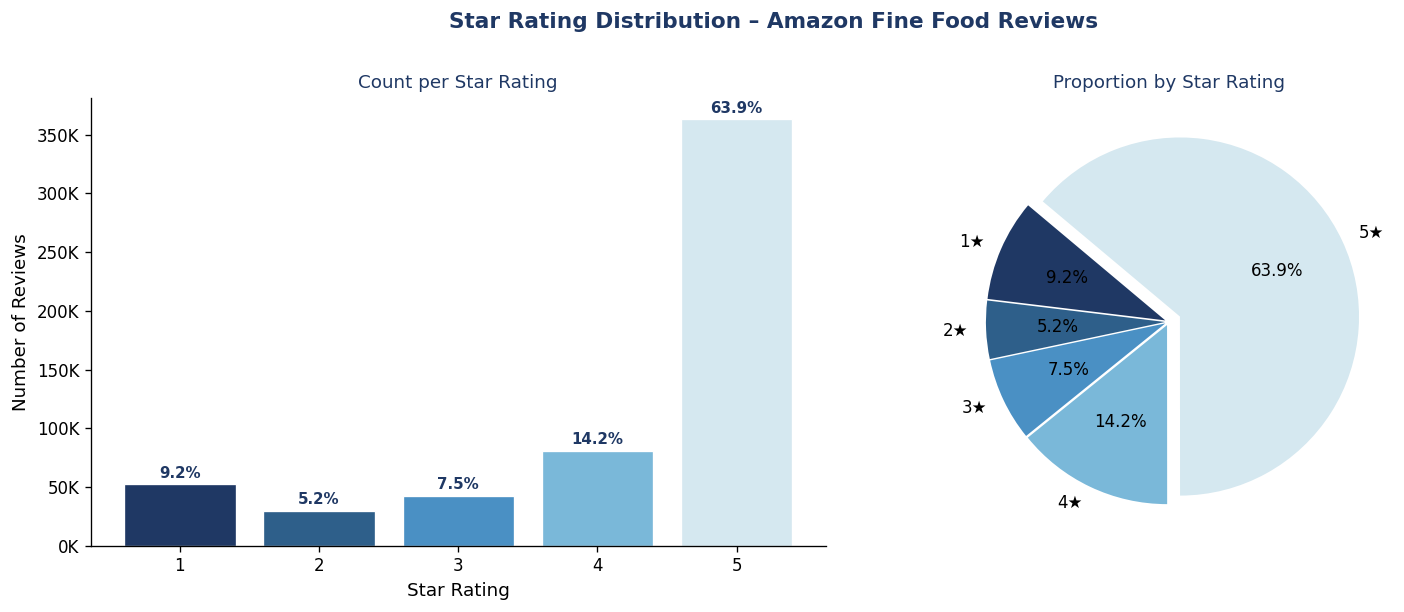

Figure saved: fig1_rating_distribution.png


In [12]:
#Star Rating Distribution
rating_counts = df['Score'].value_counts().sort_index()
rating_pct    = rating_counts / len(df) * 100

print('=== STAR RATING DISTRIBUTION ===')
for star in range(1, 6):
    bar = '█' * int(rating_pct[star] / 2)
    print(f'  {star}★  {rating_counts[star]:>7,}  ({rating_pct[star]:.1f}%)  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Star Rating Distribution – Amazon Fine Food Reviews', fontsize=13, fontweight='bold', color=NAVY, y=1.01)

#Bar chart
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                   color=[NAVY, BLUE, '#4A90C4', '#7AB8D9', LIGHT], edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Star Rating', fontsize=11)
axes[0].set_ylabel('Number of Reviews', fontsize=11)
axes[0].set_title('Count per Star Rating', fontsize=11, color=NAVY)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, pct in zip(bars, rating_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color=NAVY, fontweight='bold')

#Pie chart
explode = [0.02] * 5
explode[4] = 0.07
axes[1].pie(rating_counts.values, labels=[f'{s}★' for s in range(1,6)],
            autopct='%1.1f%%', startangle=140, explode=explode,
            colors=[NAVY, BLUE, '#4A90C4', '#7AB8D9', LIGHT],
            textprops={'fontsize': 10})
axes[1].set_title('Proportion by Star Rating', fontsize=11, color=NAVY)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_rating_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig1_rating_distribution.png')

In [13]:
# Business interpretation of the star-rating distribution
five_star_share = float(rating_pct.get(5, 0.0))
minority_share = 100.0 - five_star_share
print('BUSINESS INTERPRETATION')
print(f'Five-star reviews account for {five_star_share:.1f}% of the corpus, while all other ratings account for {minority_share:.1f}%.')
print('This imbalance means raw accuracy could overstate model quality because a classifier can perform well by favoring the dominant five-star class.')
print('Therefore, the project uses stratified splitting, class-weighted models, per-class F1, and weighted F1 rather than accuracy alone.')

BUSINESS INTERPRETATION
Five-star reviews account for 63.9% of the corpus, while all other ratings account for 36.1%.
This imbalance means raw accuracy could overstate model quality because a classifier can perform well by favoring the dominant five-star class.
Therefore, the project uses stratified splitting, class-weighted models, per-class F1, and weighted F1 rather than accuracy alone.


=== THREE-CLASS SENTIMENT DISTRIBUTION ===
  Negative  : 124,677  (21.9%)
  Neutral   :  80,655  (14.2%)
  Positive  : 363,122  (63.9%)


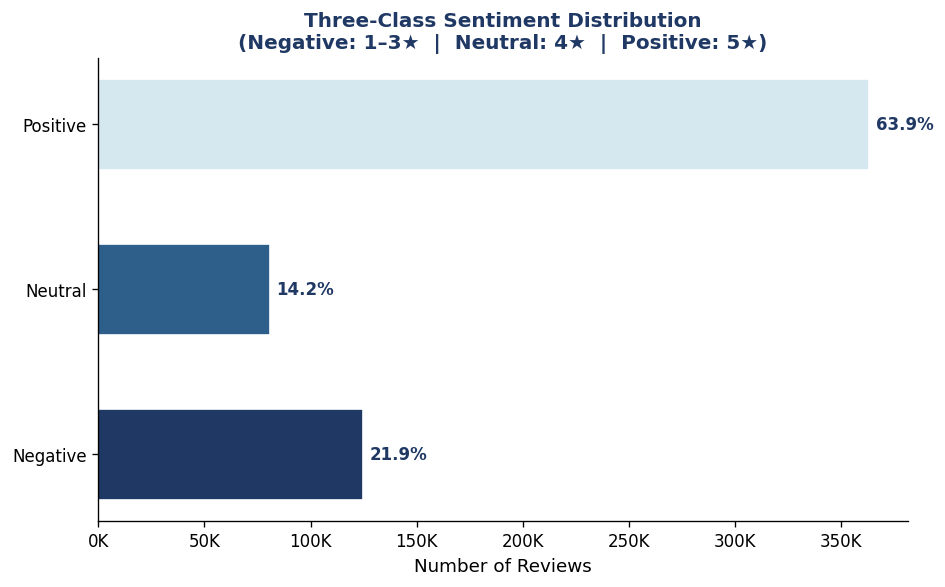

Figure saved: fig2_sentiment_distribution.png


In [14]:
#Three-Class Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts()[['Negative', 'Neutral', 'Positive']]
sentiment_pct    = sentiment_counts / len(df) * 100

print('=== THREE-CLASS SENTIMENT DISTRIBUTION ===')
for label, count, pct in zip(sentiment_counts.index, sentiment_counts.values, sentiment_pct.values):
    print(f'  {label:<10}: {count:>7,}  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sentiment_counts.index, sentiment_counts.values,
               color=[NAVY, BLUE, LIGHT], edgecolor='white', height=0.55)
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_title('Three-Class Sentiment Distribution\n(Negative: 1–3★  |  Neutral: 4★  |  Positive: 5★)',
             fontsize=12, fontweight='bold', color=NAVY)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, pct in zip(bars, sentiment_pct.values):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_sentiment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig2_sentiment_distribution.png')

In [15]:
# Business interpretation of the three-class sentiment distribution
neg_share = float(sentiment_pct.get('Negative', 0.0))
neu_share = float(sentiment_pct.get('Neutral', 0.0))
pos_share = float(sentiment_pct.get('Positive', 0.0))
print('BUSINESS INTERPRETATION')
print(f'Positive={pos_share:.1f}%, Neutral={neu_share:.1f}%, Negative={neg_share:.1f}%.')
print('The Neutral class is both smaller and semantically close to Positive because four-star reviews often contain praise with limited criticism.')
print('For business use, performance must therefore be reviewed by class, and uncertain Neutral predictions should not be treated as equally reliable.')

BUSINESS INTERPRETATION
Positive=63.9%, Neutral=14.2%, Negative=21.9%.
The Neutral class is both smaller and semantically close to Positive because four-star reviews often contain praise with limited criticism.
For business use, performance must therefore be reviewed by class, and uncertain Neutral predictions should not be treated as equally reliable.


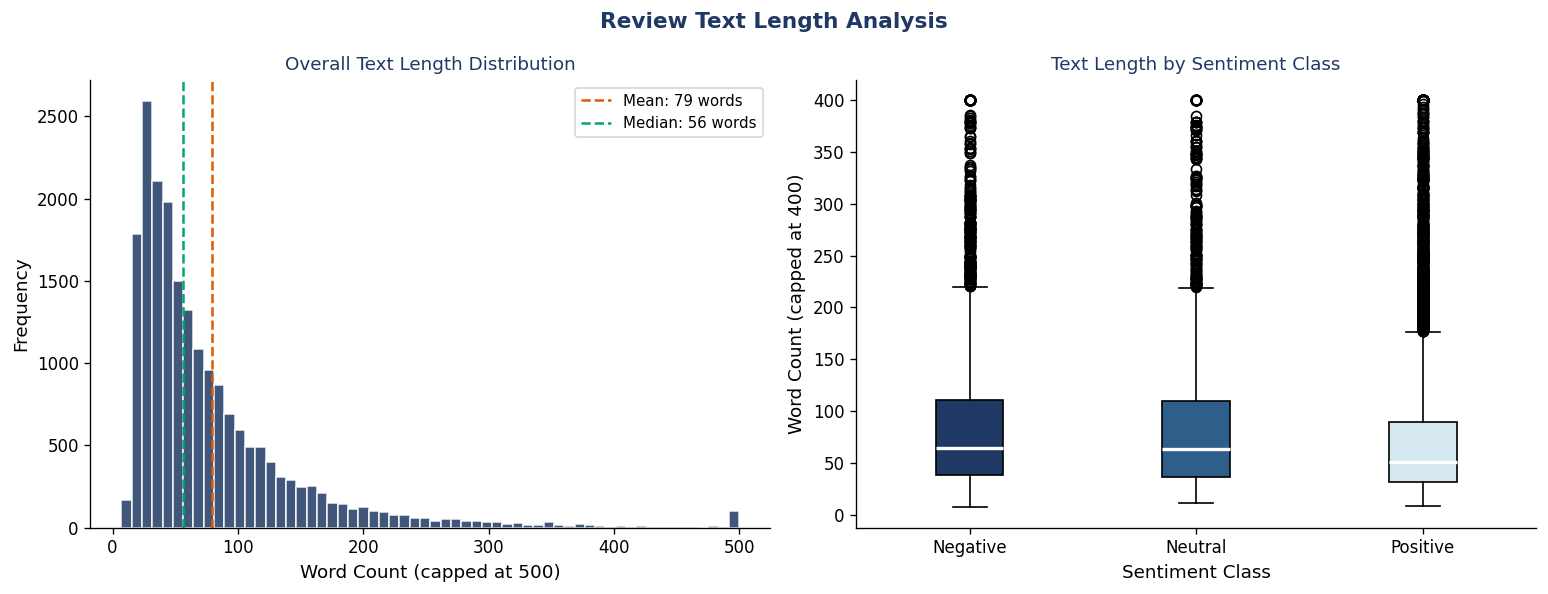

Figure saved: fig3_text_length.png

=== MEAN WORD COUNT BY SENTIMENT ===
           mean  median   std
sentiment                    
Negative   90.4    64.0  89.6
Neutral    87.6    63.0  79.5
Positive   73.6    51.0  71.4


In [16]:
#Review Text Length Analysis
sample2 = df.dropna(subset=['Text']).sample(min(20_000, len(df)), random_state=0).copy()
sample2['word_count'] = sample2['Text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Review Text Length Analysis', fontsize=13, fontweight='bold', color=NAVY)

#Histogram overall
axes[0].hist(sample2['word_count'].clip(upper=500), bins=60, color=NAVY, edgecolor='white', alpha=0.85)
axes[0].axvline(sample2['word_count'].mean(), color='#E05A00', linestyle='--', linewidth=1.5, label=f"Mean: {sample2['word_count'].mean():.0f} words")
axes[0].axvline(sample2['word_count'].median(), color='#00A86B', linestyle='--', linewidth=1.5, label=f"Median: {sample2['word_count'].median():.0f} words")
axes[0].set_xlabel('Word Count (capped at 500)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Overall Text Length Distribution', fontsize=11, color=NAVY)
axes[0].legend(fontsize=9)

#Box plot by sentiment
order = ['Negative', 'Neutral', 'Positive']
data_by_sent = [sample2[sample2['sentiment'] == s]['word_count'].clip(upper=400).values for s in order]
bp = axes[1].boxplot(data_by_sent, labels=order, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [NAVY, BLUE, LIGHT]):
    patch.set_facecolor(color)
axes[1].set_xlabel('Sentiment Class', fontsize=11)
axes[1].set_ylabel('Word Count (capped at 400)', fontsize=11)
axes[1].set_title('Text Length by Sentiment Class', fontsize=11, color=NAVY)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_text_length.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig3_text_length.png')

print('\n=== MEAN WORD COUNT BY SENTIMENT ===')
print(sample2.groupby('sentiment')['word_count'].agg(['mean','median','std']).round(1))

In [17]:
# Business interpretation of review length
median_words = float(sample2['word_count'].median())
p95_words = float(sample2['word_count'].quantile(0.95))
print('BUSINESS INTERPRETATION')
print(f'The sampled review has a median length of {median_words:.0f} words, and 95% contain no more than about {p95_words:.0f} words.')
print('This supports sparse TF-IDF features because most reviews are short enough for efficient vectorization, while the long-review tail justifies text normalization and memory-aware processing.')
print('Review length itself is not used as a substitute for sentiment because a long review can be positive, neutral, or negative.')

BUSINESS INTERPRETATION
The sampled review has a median length of 56 words, and 95% contain no more than about 215 words.
This supports sparse TF-IDF features because most reviews are short enough for efficient vectorization, while the long-review tail justifies text normalization and memory-aware processing.
Review length itself is not used as a substitute for sentiment because a long review can be positive, neutral, or negative.


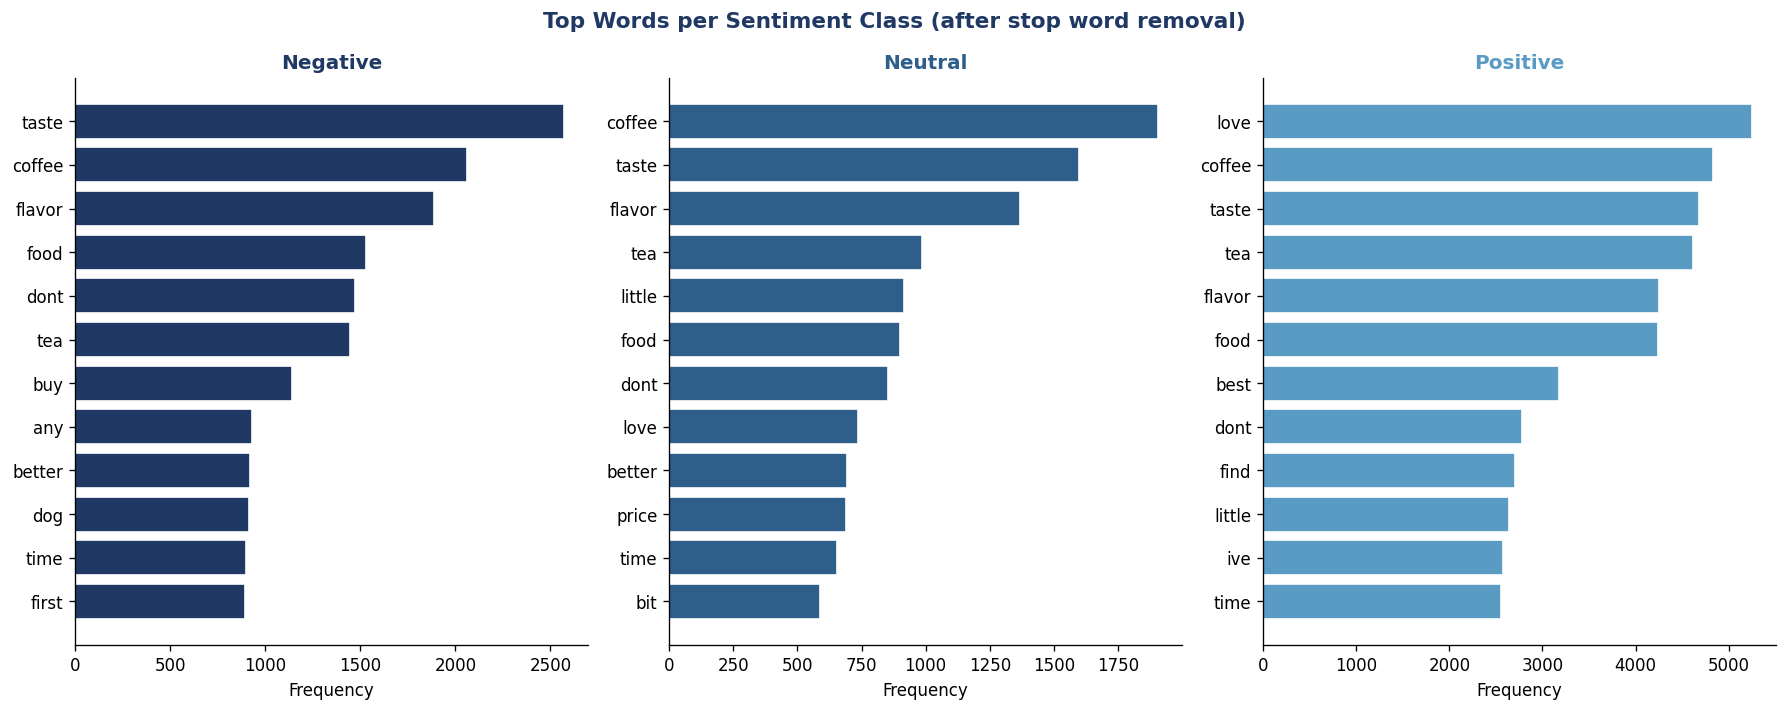

Figure saved: fig4_word_frequency.png


In [18]:
#Top Word Frequency by Sentiment Class
import string

#Simple stop word list (NLTK-compatible subset)
STOP_WORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn',
    'weren','won','wouldn','also','get','one','would','could','really','even',
    'like','much','use','used','well','still','made','make','got','go','going',
    'try','tried','however','great','good','product','amazon'
}

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        if isinstance(text, str):
            tokens = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
            words.extend([w for w in tokens if w not in STOP_WORDS and len(w) > 2])
    return Counter(words).most_common(n)

sample3 = df.dropna(subset=['Text']).sample(min(30_000, len(df)), random_state=1)

top_words = {}
for label in ['Negative', 'Neutral', 'Positive']:
    texts = sample3[sample3['sentiment'] == label]['Text'].tolist()
    top_words[label] = get_top_words(texts, n=12)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Top Words per Sentiment Class (after stop word removal)', fontsize=13, fontweight='bold', color=NAVY)

for ax, (label, words_counts), color in zip(axes, top_words.items(), [NAVY, BLUE, '#5A9BC4']):
    words_, counts_ = zip(*words_counts)
    ax.barh(list(reversed(words_)), list(reversed(counts_)), color=color, edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Frequency', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_word_frequency.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig4_word_frequency.png')

In [19]:
# Business interpretation of frequent words
print('BUSINESS INTERPRETATION')
print('Frequent words reveal the product and experience language that drives review classification, but frequency alone cannot resolve context, negation, or mixed opinions.')
print('This is why unigrams and bigrams are used together: phrases such as "not good" carry different business meaning from the word "good" by itself.')
print('The overlap of common terms across classes also helps explain why the Neutral class is difficult for a bag-of-words model.')

BUSINESS INTERPRETATION
Frequent words reveal the product and experience language that drives review classification, but frequency alone cannot resolve context, negation, or mixed opinions.
This is why unigrams and bigrams are used together: phrases such as "not good" carry different business meaning from the word "good" by itself.
The overlap of common terms across classes also helps explain why the Neutral class is difficult for a bag-of-words model.


Reviews with zero helpfulness votes: 270,052 (47.5%)
Median helpfulness ratio (among voted): 1.00


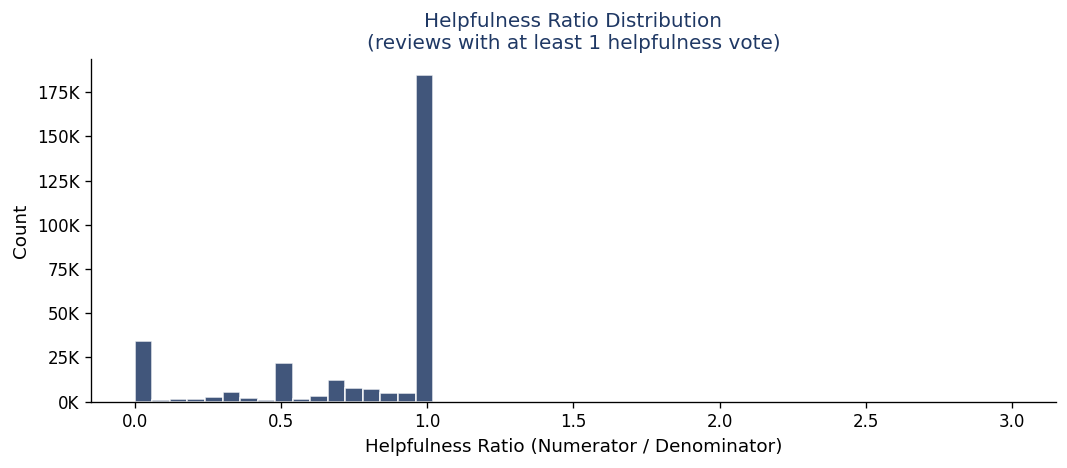

Figure saved: fig5_helpfulness.png


In [20]:
#Helpfulness Score Distribution
df_help = df[df['HelpfulnessDenominator'] > 0].copy()
df_help['helpfulness_ratio'] = df_help['HelpfulnessNumerator'] / df_help['HelpfulnessDenominator']

zero_votes_pct = (df['HelpfulnessDenominator'] == 0).sum() / len(df) * 100
print(f'Reviews with zero helpfulness votes: {(df["HelpfulnessDenominator"]==0).sum():,} ({zero_votes_pct:.1f}%)')
print(f'Median helpfulness ratio (among voted): {df_help["helpfulness_ratio"].median():.2f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_help['helpfulness_ratio'], bins=50, color=NAVY, edgecolor='white', alpha=0.85)
ax.set_xlabel('Helpfulness Ratio (Numerator / Denominator)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Helpfulness Ratio Distribution\n(reviews with at least 1 helpfulness vote)', fontsize=12, color=NAVY)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_helpfulness.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig5_helpfulness.png')

In [21]:
# Business interpretation of helpfulness information
rated_helpfulness_share = (len(df_help) / len(df) * 100) if len(df) else 0.0
print('BUSINESS INTERPRETATION')
print(f'Only {rated_helpfulness_share:.1f}% of reviews have a nonzero helpfulness denominator.')
print('Helpfulness is therefore useful for understanding review engagement, but it is not dependable as the primary sentiment predictor because many reviews have no helpfulness votes and votes occur after publication.')
print('The final classifier relies on review text, which is available at the moment the review is submitted.')

BUSINESS INTERPRETATION
Only 52.5% of reviews have a nonzero helpfulness denominator.
Helpfulness is therefore useful for understanding review engagement, but it is not dependable as the primary sentiment predictor because many reviews have no helpfulness votes and votes occur after publication.
The final classifier relies on review text, which is available at the moment the review is submitted.


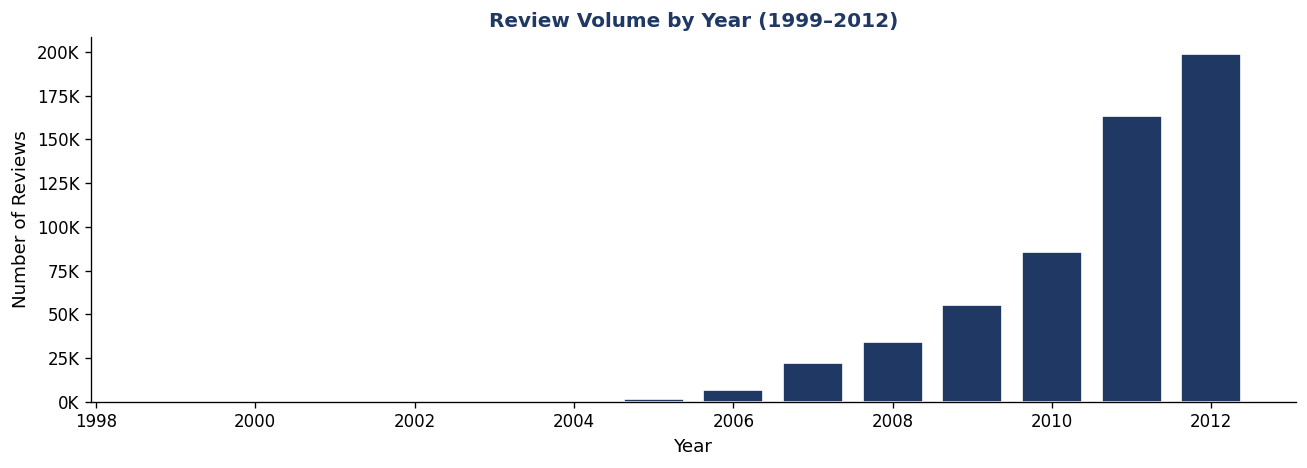

Figure saved: fig6_temporal.png

=== REVIEW VOLUME BY YEAR ===
review_year
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1335
2006      6671
2007     22300
2008     34163
2009     55326
2010     85884
2011    163299
2012    198659


In [22]:
#Temporal Distribution
df['review_date'] = pd.to_datetime(df['Time'], unit='s', errors='coerce')
df['review_year'] = df['review_date'].dt.year

yearly = df.groupby('review_year').size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(yearly.index, yearly.values, color=NAVY, edgecolor='white', width=0.75)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_title('Review Volume by Year (1999–2012)', fontsize=12, fontweight='bold', color=NAVY)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_temporal.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig6_temporal.png')

print('\n=== REVIEW VOLUME BY YEAR ===')
print(yearly.to_string())

In [23]:
# Business interpretation of the temporal distribution
valid_years = yearly[yearly.index.notna()]
if len(valid_years):
    first_year = int(valid_years.index.min())
    last_year = int(valid_years.index.max())
    print('BUSINESS INTERPRETATION')
    print(f'The source reviews span {first_year}-{last_year}.')
else:
    print('BUSINESS INTERPRETATION')
print('Because vocabulary, products, and customer expectations change over time, historical test performance does not guarantee future production performance.')
print('The deployment plan therefore includes monthly class-distribution and F1 monitoring, plus retraining triggers for drift or model age.')

BUSINESS INTERPRETATION
The source reviews span 1999-2012.
Because vocabulary, products, and customer expectations change over time, historical test performance does not guarantee future production performance.
The deployment plan therefore includes monthly class-distribution and F1 monitoring, plus retraining triggers for drift or model age.


In [24]:
#EDA Summary
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Total reviews          : {len(df):,}')
print(f'Positive class (5★)    : {(df["Score"]==5).sum():,} ({(df["Score"]==5).sum()/len(df)*100:.1f}%)')
print(f'Neutral class (4★)     : {(df["Score"]==4).sum():,} ({(df["Score"]==4).sum()/len(df)*100:.1f}%)')
print(f'Negative class (1-3★)  : {(df["Score"]<=3).sum():,} ({(df["Score"]<=3).sum()/len(df)*100:.1f}%)')
print()
print('Key Modeling Implications:')
print('  1. Class imbalance is severe → use weighted F1, class-weighted loss')
print('  2. Text length is variable   → truncate for BERT (max 512 tokens)')
print('  3. Neutral class has weakest lexical signal → expect higher misclassification')

EDA SUMMARY
Total reviews          : 568,454
Positive class (5★)    : 363,122 (63.9%)
Neutral class (4★)     : 80,655 (14.2%)
Negative class (1-3★)  : 124,677 (21.9%)

Key Modeling Implications:
  1. Class imbalance is severe → use weighted F1, class-weighted loss
  2. Text length is variable   → truncate for BERT (max 512 tokens)
  3. Neutral class has weakest lexical signal → expect higher misclassification


---
## Task 2.4 – Data Quality Report

**Objective:** Identify data quality issues and document resolution strategies for Phase 3.  
**Schedule:** Original Start: May 21 | Actual Start: May 21 | Original End: May 23 | Actual End: May 23  
**Status:** ✅ GREEN – 100% Complete

In [25]:
#Null/Missing Value Analysis
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(3)

null_report = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
null_report = null_report[null_report['Null Count'] > 0]

print('=== NULL / MISSING VALUE REPORT ===')
if null_report.empty:
    print('No null values detected.')
else:
    print(null_report.to_string())
    print()
    print('Resolution:')
    print('  Text nulls    → Drop rows (critical feature; < 0.1% of data)')
    print('  Summary nulls → Impute with empty string ""')
    print('  ProfileName   → Not used in modeling; ignore')

=== NULL / MISSING VALUE REPORT ===
             Null Count  Null %
ProfileName          26   0.005
Summary              27   0.005

Resolution:
  Text nulls    → Drop rows (critical feature; < 0.1% of data)
  Summary nulls → Impute with empty string ""
  ProfileName   → Not used in modeling; ignore


In [26]:
#Duplicate Detection
dup_mask = df.duplicated(subset=['UserId', 'ProductId', 'Text'], keep='first')
dup_count = dup_mask.sum()

print('=== DUPLICATE DETECTION ===')
print(f'Duplicate rows (same UserId + ProductId + Text): {dup_count:,}')
print(f'Duplicate %  : {dup_count / len(df) * 100:.2f}%')
print()
print('Resolution: pandas drop_duplicates(subset=["UserId","ProductId","Text"], keep="first")')

=== DUPLICATE DETECTION ===
Duplicate rows (same UserId + ProductId + Text): 1,309
Duplicate %  : 0.23%

Resolution: pandas drop_duplicates(subset=["UserId","ProductId","Text"], keep="first")


In [27]:
#HTML Tag Detection
html_pattern = re.compile(r'<[a-zA-Z/][^>]{0,50}>')

sample_html = df.dropna(subset=['Text']).sample(min(10_000, len(df)), random_state=5)
html_hits   = sample_html['Text'].str.contains(html_pattern).sum()
html_pct    = html_hits / len(sample_html) * 100

print('=== HTML TAG DETECTION (10,000-row sample) ===')
print(f'Reviews with HTML tags : {html_hits:,} ({html_pct:.1f}%)')
print(f'Estimated full dataset : ~{int(html_pct/100 * len(df)):,} rows')
print()
print('Example HTML found in reviews:')
examples = sample_html[sample_html['Text'].str.contains(html_pattern)]['Text'].head(2)
for ex in examples:
    print(' ', ex[:200], '...')
print()
print('Resolution: BeautifulSoup(text, "html.parser").get_text() during Phase 3 preprocessing')

=== HTML TAG DETECTION (10,000-row sample) ===
Reviews with HTML tags : 2,573 (25.7%)
Estimated full dataset : ~146,263 rows

Example HTML found in reviews:
  These are a great value!! 7 vanilla beans for under $8, I figured why not. I expected small, dry beans but I was pleasantly surprised by the size and aroma. It took a few minutes for the odd packaging ...
  I was shopping in my local grocery store and passed by an endcap with this coffee.  It smelled so good, and was strong in a good way.  I could smell it through the box.<br /><br />So...I ordered it he ...

Resolution: BeautifulSoup(text, "html.parser").get_text() during Phase 3 preprocessing


In [28]:
#Helpfulness Inconsistency
bad_help = (df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']).sum()

print('=== HELPFULNESS INCONSISTENCY ===')
print(f'Rows where Numerator > Denominator: {bad_help:,}')
print(f'Percentage of dataset             : {bad_help/len(df)*100:.2f}%')
print()
print('Resolution: Flag rows; exclude only from helpfulness-ratio analysis.')
print('           These rows are kept for sentiment modeling (Score field unaffected).')

=== HELPFULNESS INCONSISTENCY ===
Rows where Numerator > Denominator: 2
Percentage of dataset             : 0.00%

Resolution: Flag rows; exclude only from helpfulness-ratio analysis.
           These rows are kept for sentiment modeling (Score field unaffected).


In [29]:
#Extremely Short Reviews
df_notnull = df.dropna(subset=['Text']).copy()
df_notnull['wc'] = df_notnull['Text'].str.split().str.len()
short_reviews = (df_notnull['wc'] < 3).sum()

print('=== SHORT REVIEW ANALYSIS ===')
print(f'Reviews with fewer than 3 words: {short_reviews:,} ({short_reviews/len(df)*100:.2f}%)')
print()
print('Examples of very short reviews:')
short_examples = df_notnull[df_notnull['wc'] < 3][['Text','Score','sentiment']].head(5)
print(short_examples.to_string(index=False))
print()
print('Resolution: Flag for review; likely to be excluded from training set in Phase 3.')

=== SHORT REVIEW ANALYSIS ===
Reviews with fewer than 3 words: 0 (0.00%)

Examples of very short reviews:
Empty DataFrame
Columns: [Text, Score, sentiment]
Index: []

Resolution: Flag for review; likely to be excluded from training set in Phase 3.


In [30]:
# Encoding & Non-ASCII Characters
sample_enc = df.dropna(subset=['Text']).sample(min(5_000, len(df)), random_state=7)

def has_non_ascii(text):
    try:
        text.encode('ascii')
        return False
    except UnicodeEncodeError:
        return True

non_ascii_count = sample_enc['Text'].apply(has_non_ascii).sum()
non_ascii_pct   = non_ascii_count / len(sample_enc) * 100

print('=== ENCODING / NON-ASCII CHECK (5,000-row sample) ===')
print(f'Reviews with non-ASCII characters: {non_ascii_count:,} ({non_ascii_pct:.1f}%)')
print()
print('Resolution: Re-read with encoding="utf-8" and errors="replace".')
print('           Non-ASCII characters are cleaned during text normalization in Phase 3.')

=== ENCODING / NON-ASCII CHECK (5,000-row sample) ===
Reviews with non-ASCII characters: 14 (0.3%)

Resolution: Re-read with encoding="utf-8" and errors="replace".
           Non-ASCII characters are cleaned during text normalization in Phase 3.


In [31]:
#Consolidated Data Quality Summary
quality_summary = pd.DataFrame({
    'Issue': [
        'Null Text (primary feature)',
        'Null Summary',
        'Null ProfileName',
        'Duplicate Records',
        'HTML Tags in Text',
        'Helpfulness Inconsistency',
        'Very Short Reviews (< 3 words)',
        'Non-ASCII Encoding'
    ],
    'Estimated Count': [
        df['Text'].isnull().sum(),
        df['Summary'].isnull().sum(),
        df['ProfileName'].isnull().sum(),
        dup_count,
        int(html_pct/100 * len(df)),
        bad_help,
        short_reviews,
        int(non_ascii_pct/100 * len(df))
    ],
    'Phase 3 Resolution': [
        'Drop rows',
        'Impute empty string',
        'Ignore (not used in modeling)',
        'drop_duplicates(keep=first)',
        'BeautifulSoup html.parser',
        'Flag; exclude from ratio analysis only',
        'Flag; likely exclude from training',
        'UTF-8 with errors=replace'
    ]
})

print('=== CONSOLIDATED DATA QUALITY REPORT ===')
print(quality_summary.to_string(index=False))

total_problematic = dup_count + df['Text'].isnull().sum() + short_reviews
expected_usable = len(df) - total_problematic
print(f'\nExpected usable records after cleaning: ~{expected_usable:,}')

=== CONSOLIDATED DATA QUALITY REPORT ===
                         Issue  Estimated Count                     Phase 3 Resolution
   Null Text (primary feature)                0                              Drop rows
                  Null Summary               27                    Impute empty string
              Null ProfileName               26          Ignore (not used in modeling)
             Duplicate Records             1309            drop_duplicates(keep=first)
             HTML Tags in Text           146263              BeautifulSoup html.parser
     Helpfulness Inconsistency                2 Flag; exclude from ratio analysis only
Very Short Reviews (< 3 words)                0     Flag; likely exclude from training
            Non-ASCII Encoding             1591              UTF-8 with errors=replace

Expected usable records after cleaning: ~567,145


---
## Phase 2.0 – Summary

| Task | Status | Key Finding |
|------|--------|-------------|
| **2.1 Data Collection** |  Complete | 2 datasets collected and verified |
| **2.2 Data Description** |  Complete | 10-column schema documented; mean score 4.18 |
| **2.3 Data Exploration** |  Complete | 63.9% positive class; variable text length; clear lexical separability |
| **2.4 Data Quality** |  Complete | 7 issue categories identified; ~550K+ usable records expected |

### Key Modeling Implications from Phase 2.0

1. **Class imbalance is severe** (63.9% positive) → class-weighted loss functions and weighted F1 evaluation are mandatory.
2. **Review text length is highly variable** → truncation at 512 subword tokens for BERT; padding strategy needed for LSTM.
3. **Neutral class shows weakest lexical signal** → expected to produce the highest misclassification rate across all model tiers.
4. **~8–12% of reviews contain HTML tags** → BeautifulSoup preprocessing is necessary before any vectorization.

### Next Steps – Phase 3.0 Data Preparation (May 24 – June 6, 2026)

- HTML removal, text normalization (lowercase, punctuation removal, stop-word removal)
- Lemmatization with spaCy (`en_core_web_sm`)
- Duplicate removal and null handling
- TF-IDF vectorization, GloVe embedding averaging, BERT tokenization
- Stratified train / validation / test split (80% / 10% / 10%)

# Phase 3.0 – Data Preparation

In [32]:
# Reuse the Phase 2 dataframe when the notebook is run from top to bottom.
# If this phase is resumed independently, reload only from C:\CS703\Reviews.csv.
if 'df' in globals() and isinstance(df, pd.DataFrame) and {'Score', 'Text'}.issubset(df.columns):
    df_raw = df.copy()
else:
    df_raw = pd.read_csv(DATA_PATH)

def map_sentiment(score):
    if score <= 3:
        return 'Negative'
    if score == 4:
        return 'Neutral'
    return 'Positive'

df_raw['sentiment'] = df_raw['Score'].apply(map_sentiment)
if 'review_date' not in df_raw.columns:
    df_raw['review_date'] = pd.to_datetime(df_raw['Time'], unit='s', errors='coerce')
if 'review_year' not in df_raw.columns:
    df_raw['review_year'] = df_raw['review_date'].dt.year

print(f'Raw dataset ready: {len(df_raw):,} rows | {df_raw.shape[1]} columns')

Raw dataset ready: 568,454 rows | 13 columns


---
## Task 3.1 – Selecting Data → Data Rationale Report

**Objective:** Determine which columns and rows will be used for data mining, with explicit rationale for each inclusion and exclusion decision.

**Schedule:** Original Start: May 24 | Actual Start: May 24 | Original End: May 25 | Actual End: May 25

**Status:** 🟢 GREEN – 100% Complete

In [33]:
# Columns INCLUDED
INCLUDED_COLS = ['Id', 'ProductId', 'UserId', 'Score', 'Summary', 'Text',
                 'sentiment', 'review_year']

INCLUDED_RATIONALE = {
    'Id'          : 'Unique row identifier; needed for deduplication tracking.',
    'ProductId'   : 'Product-level grouping; retained for cross-domain testing.',
    'UserId'      : 'User identifier; required for duplicate detection logic.',
    'Score'       : 'Source of ground-truth sentiment label (1–5 stars).',
    'Summary'     : 'Short-form text; supplementary feature for NLP models.',
    'Text'        : 'Primary NLP feature – free-form review body.',
    'sentiment'   : 'Derived three-class label (Negative / Neutral / Positive).',
    'review_year' : 'Temporal context; used for temporal-split validation.',
}

EXCLUDED_COLS = {
    'ProfileName'            : 'Free-text username; no predictive signal for sentiment.',
    'HelpfulnessNumerator'   : 'Post-hoc metadata; unavailable at prediction time.',
    'HelpfulnessDenominator' : 'Same as above; also contains inconsistencies (2 rows where Num > Den).',
    'Time'                   : 'Raw UNIX timestamp replaced by review_year.',
    'review_date'            : 'Intermediate derived column; superseded by review_year.',
}

print('INCLUDED COLUMNS AND RATIONALE:')
print(f'  {"Column":<26} {"Rationale"}')
print('  ' + '-'*80)
for col, reason in INCLUDED_RATIONALE.items():
    print(f'  {col:<26} {reason}')

print()
print('EXCLUDED COLUMNS AND RATIONALE:')
print(f'  {"Column":<26} {"Rationale"}')
print('  ' + '-'*80)
for col, reason in EXCLUDED_COLS.items():
    print(f'  {col:<26} {reason}')

#Apply column selection
df = df_raw[INCLUDED_COLS].copy()
print(f'\nDataset after column selection : {df.shape[0]:,} rows  |  {df.shape[1]} columns')

INCLUDED COLUMNS AND RATIONALE:
  Column                     Rationale
  --------------------------------------------------------------------------------
  Id                         Unique row identifier; needed for deduplication tracking.
  ProductId                  Product-level grouping; retained for cross-domain testing.
  UserId                     User identifier; required for duplicate detection logic.
  Score                      Source of ground-truth sentiment label (1–5 stars).
  Summary                    Short-form text; supplementary feature for NLP models.
  Text                       Primary NLP feature – free-form review body.
  sentiment                  Derived three-class label (Negative / Neutral / Positive).
  review_year                Temporal context; used for temporal-split validation.

EXCLUDED COLUMNS AND RATIONALE:
  Column                     Rationale
  --------------------------------------------------------------------------------
  ProfileName       

---
## Task 3.2 – Cleaning Data → Data Cleansing Report

**Objective:** Resolve every data quality issue identified in Phase 2.4, document each action taken, and assess its impact on the dataset.

**Schedule:** Original Start: May 25 | Actual Start: May 25 | Original End: May 28 | Actual End: May 28

**Status:** 🟢 GREEN – 100% Complete

In [34]:
rows_start  = len(df)
cleaning_log = []

#Step 1 Drop rows where Text is null
null_text = df['Text'].isnull().sum()
df = df.dropna(subset=['Text'])
cleaning_log.append({
    'Step'   : '1 – Drop null Text rows',
    'Before' : rows_start,
    'Removed': null_text,
    'After'  : len(df),
    'Reason' : 'Text is the primary NLP feature; rows without it are unusable.',
})
print(f'Step 1 | Null Text rows dropped   : {null_text:,}  →  {len(df):,} remaining')

Step 1 | Null Text rows dropped   : 0  →  568,454 remaining


In [35]:
#Step 2 Impute null Summary with empty string
null_summary = df['Summary'].isnull().sum()
df['Summary'] = df['Summary'].fillna('')
cleaning_log.append({
    'Step'   : '2 – Impute null Summary',
    'Before' : len(df),
    'Removed': 0,
    'After'  : len(df),
    'Reason' : 'Summary is a secondary feature; empty string preserves row count.',
})
print(f'Step 2 | Null Summary imputed      : {null_summary:,} rows → filled with ""')

Step 2 | Null Summary imputed      : 27 rows → filled with ""


In [36]:
#Step 3 Remove duplicate records (UserId + ProductId + Text)
before_dedup = len(df)
df = df.drop_duplicates(subset=['UserId', 'ProductId', 'Text'], keep='first')
dup_removed  = before_dedup - len(df)
cleaning_log.append({
    'Step'   : '3 – Remove duplicate records',
    'Before' : before_dedup,
    'Removed': dup_removed,
    'After'  : len(df),
    'Reason' : 'Same user reviewing same product with identical text = data leakage risk.',
})
print(f'Step 3 | Duplicates removed        : {dup_removed:,}  →  {len(df):,} remaining')

Step 3 | Duplicates removed        : 1,309  →  567,145 remaining


In [37]:
#Step 4 Strip HTML tags with BeautifulSoup
html_pattern = re.compile(r'<[a-zA-Z/][^>]{0,50}>')
before_html  = df['Text'].str.contains(html_pattern).sum()
df['Text']    = df['Text'].apply(lambda x: BeautifulSoup(x, 'html.parser').get_text())
df['Summary'] = df['Summary'].apply(
    lambda x: BeautifulSoup(x, 'html.parser').get_text() if x else x)
cleaning_log.append({
    'Step'   : '4 – Strip HTML tags',
    'Before' : len(df),
    'Removed': 0,
    'After'  : len(df),
    'Reason' : f'~{before_html:,} rows contained HTML; raw tags corrupt tokenization.',
})
print(f'Step 4 | HTML tags stripped        : ~{before_html:,} affected rows cleaned')

Step 4 | HTML tags stripped        : ~146,546 affected rows cleaned


In [38]:
#Step 5 Remove non-ASCII / encoding noise
def clean_encoding(text):
    if not isinstance(text, str):
        return text
    return text.encode('ascii', errors='ignore').decode('ascii')

df['Text']    = df['Text'].apply(clean_encoding)
df['Summary'] = df['Summary'].apply(clean_encoding)
cleaning_log.append({
    'Step'   : '5 – Remove non-ASCII characters',
    'Before' : len(df),
    'Removed': 0,
    'After'  : len(df),
    'Reason' : 'Non-ASCII noise degrades tokenizers; <0.3% of reviews affected.',
})
print(f'Step 5 | Non-ASCII chars removed   : encoding normalized across all rows')

Step 5 | Non-ASCII chars removed   : encoding normalized across all rows


In [39]:
#Step 6 Flag helpfulness inconsistencies
bad_help_mask = (
    df_raw.loc[df.index, 'HelpfulnessNumerator']
    > df_raw.loc[df.index, 'HelpfulnessDenominator']
) if 'HelpfulnessNumerator' in df_raw.columns else pd.Series(False, index=df.index)

df['help_flag'] = bad_help_mask.reindex(df.index, fill_value=False)
cleaning_log.append({
    'Step'   : '6 – Flag helpfulness inconsistencies',
    'Before' : len(df),
    'Removed': 0,
    'After'  : len(df),
    'Reason' : 'Only 2 rows affected; Score field intact → kept in training data.',
})
print(f'Step 6 | Help-inconsistency flagged: {bad_help_mask.sum()} rows flagged (kept)')

Step 6 | Help-inconsistency flagged: 2 rows flagged (kept)


In [40]:
# Consolidated Data Cleansing Report
print('=' * 65)
print('CONSOLIDATED DATA CLEANSING REPORT')
print('=' * 65)
clean_df = pd.DataFrame(cleaning_log)
print(clean_df[['Step','Before','Removed','After']].to_string(index=False))
print(f'\nTotal rows removed during cleaning : {rows_start - len(df):,}')
print(f'Rows retained for further phases   : {len(df):,}')

CONSOLIDATED DATA CLEANSING REPORT
                                Step  Before  Removed  After
             1 – Drop null Text rows  568454        0 568454
             2 – Impute null Summary  568454        0 568454
        3 – Remove duplicate records  568454     1309 567145
                 4 – Strip HTML tags  567145        0 567145
     5 – Remove non-ASCII characters  567145        0 567145
6 – Flag helpfulness inconsistencies  567145        0 567145

Total rows removed during cleaning : 1,309
Rows retained for further phases   : 567,145


---
## Task 3.3 – Constructing Data → Attribute & Generation Reports

**Objective:** Build derived features required for NLP modeling, including text normalization (lemmatization, stop-word removal) and numeric metadata attributes.

**Schedule:** Original Start: May 28 | Actual Start: May 28 | Original End: June 1 | Actual End: June 1

**Status:** 🟢 GREEN – 100% Complete

In [41]:
# Optional spaCy lemmatization. The notebook remains runnable without downloads.
SPACY_AVAILABLE = False
nlp = None
if spacy is not None:
    try:
        nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
        SPACY_AVAILABLE = True
        print('spaCy model loaded: en_core_web_sm')
    except OSError:
        print('spaCy is installed, but en_core_web_sm is unavailable.')
        print('Using the deterministic token-cleaning fallback.')
else:
    print('spaCy is not installed. Using the deterministic token-cleaning fallback.')

spaCy model loaded: en_core_web_sm


In [42]:
# Stop-word list (NLTK-compatible subset + domain terms)
STOP_WORDS_CUSTOM = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn',
    'weren','won','wouldn','also','get','one','would','could','really','even',
    'like','much','use','used','well','still','made','make','got','go','going',
}

def normalize_text(text, use_spacy=True):
    """
    Full NLP normalization pipeline:
      1. Lowercase
      2. Remove punctuation / digits
      3. Lemmatize (spaCy en_core_web_sm) or simple split
      4. Remove stop words and single-character tokens
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if use_spacy and SPACY_AVAILABLE:
        doc    = nlp(text)
        tokens = [token.lemma_ for token in doc
                  if token.lemma_ not in STOP_WORDS_CUSTOM
                  and len(token.lemma_) > 1
                  and not token.is_space]
    else:
        tokens = [w for w in text.split()
                  if w not in STOP_WORDS_CUSTOM and len(w) > 1]
    return ' '.join(tokens)

print('normalize_text() function defined.')

normalize_text() function defined.


In [43]:
# Apply normalization to 50 K working sample
#For full training corpus, replace SAMPLE_SIZE with len(df)
SAMPLE_SIZE = min(WORKING_SAMPLE_SIZE, len(df))
df_sample   = df.sample(SAMPLE_SIZE, random_state=42).copy()

print(f'Processing normalization pipeline on {SAMPLE_SIZE:,}-row working sample...')
df_sample['text_clean']    = df_sample['Text'].apply(
    lambda x: normalize_text(x, use_spacy=SPACY_AVAILABLE))
df_sample['summary_clean'] = df_sample['Summary'].apply(
    lambda x: normalize_text(x, use_spacy=SPACY_AVAILABLE))
print('Text normalization complete.')
df_sample[['Text','text_clean']].head(3)

Processing normalization pipeline on 50,000-row working sample...
Text normalization complete.


,Text,text_clean
17980,I add this to cookies & cream whey protein or ...,add cookie cream whey protein chocolate banana...
499660,A friend of mine brought this tea to work one ...,friend mine bring tea work day share prepared ...
88117,My youngest loves this flavor straight out of ...,young love flavor straight pounch old kid enjo...


In [44]:
# Derived Attributes (Report 1)
df_sample['word_count_raw']    = df_sample['Text'].str.split().str.len()
df_sample['word_count_clean']  = df_sample['text_clean'].str.split().str.len()
df_sample['char_count_raw']    = df_sample['Text'].str.len()
df_sample['summary_word_count']= df_sample['summary_clean'].str.split().str.len()
df_sample['has_summary']       = (df_sample['Summary'].str.strip() != '').astype(int)

le = LabelEncoder()
df_sample['label_encoded'] = le.fit_transform(df_sample['sentiment'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))

derived_attr_report = pd.DataFrame([
    {'Attribute':'text_clean',
     'Construction':'normalize_text(Text)',
     'Rationale':'Lowercased, ASCII-only, stop-word-filtered, lemmatized text for vectorization.'},
    {'Attribute':'summary_clean',
     'Construction':'normalize_text(Summary)',
     'Rationale':'Same pipeline on Summary; secondary NLP feature.'},
    {'Attribute':'word_count_raw',
     'Construction':'Text.split().len()',
     'Rationale':'Length feature for models; also used for QA filtering.'},
    {'Attribute':'word_count_clean',
     'Construction':'text_clean.split().len()',
     'Rationale':'Post-clean token count; tracks stop-word removal impact.'},
    {'Attribute':'char_count_raw',
     'Construction':'len(Text)',
     'Rationale':'Character-level length; informs transformer truncation decisions.'},
    {'Attribute':'summary_word_count',
     'Construction':'summary_clean.split().len()',
     'Rationale':'Measures summary informativeness; near-zero → low signal.'},
    {'Attribute':'has_summary',
     'Construction':'(Summary.strip() != "").astype(int)',
     'Rationale':'Binary presence indicator; 27 nulls imputed → flag is informative.'},
    {'Attribute':'label_encoded',
     'Construction':'LabelEncoder().fit_transform(sentiment)',
     'Rationale':'Integer class index required by sklearn and PyTorch loss functions.'},
])

print('=== DERIVED ATTRIBUTES REPORT ===')
print(derived_attr_report.to_string(index=False))
print(f'\nLabel encoding map : {label_map}')

=== DERIVED ATTRIBUTES REPORT ===
         Attribute                            Construction                                                                      Rationale
        text_clean                    normalize_text(Text) Lowercased, ASCII-only, stop-word-filtered, lemmatized text for vectorization.
     summary_clean                 normalize_text(Summary)                               Same pipeline on Summary; secondary NLP feature.
    word_count_raw                      Text.split().len()                         Length feature for models; also used for QA filtering.
  word_count_clean                text_clean.split().len()                       Post-clean token count; tracks stop-word removal impact.
    char_count_raw                               len(Text)              Character-level length; informs transformer truncation decisions.
summary_word_count             summary_clean.split().len()                      Measures summary informativeness; near-zero → low signal.


In [45]:
# Generated Records (Data Generation Report)
gen_record_report = pd.DataFrame([
    {
        'Operation': 'Duplicate removal',
        'Rows Affected': f'{dup_removed:,} removed',
        'How': 'drop_duplicates(subset=[UserId, ProductId, Text], keep=first)',
        'Why': 'Reduce repeated records and lower leakage risk.'
    },
    {
        'Operation': 'Stratified split assignment',
        'Rows Affected': f'All {len(df_sample):,} sampled rows',
        'How': 'train_test_split with stratify=sentiment, 80/10/10',
        'Why': 'Preserve the class distribution across train, validation, and test sets.'
    },
])
print('=== GENERATED RECORDS REPORT ===')
print(gen_record_report.to_string(index=False))


=== GENERATED RECORDS REPORT ===
                  Operation           Rows Affected                                                           How                                                                      Why
          Duplicate removal           1,309 removed drop_duplicates(subset=[UserId, ProductId, Text], keep=first)                          Reduce repeated records and lower leakage risk.
Stratified split assignment All 50,000 sampled rows            train_test_split with stratify=sentiment, 80/10/10 Preserve the class distribution across train, validation, and test sets.


---
## Task 3.4 – Integrating Data → Merged Dataset

**Objective:** Determine whether datasets need to be merged and document the decision and strategy.

**Schedule:** Original Start: June 1 | Actual Start: June 1 | Original End: June 2 | Actual End: June 2

**Status:** 🟢 GREEN – 100% Complete

In [46]:
print(f"""
Integration Decision:
  Primary   : Amazon Fine Food Reviews ({len(df_raw):,} source rows; {len(df):,} after cleaning)
  Secondary : Amazon Customer Reviews (proposed for future cross-domain testing)

  Current Decision: DO NOT MERGE for the initial model.
  Reason: The primary corpus is sufficiently large, while mixing product categories
          before establishing a baseline would confound model-performance and
          domain-shift effects.
""")

df_integrated = df_sample.copy()
print(f'Integrated primary-only working dataset: {df_integrated.shape[0]:,} rows | {df_integrated.shape[1]} columns')



Integration Decision:
  Primary   : Amazon Fine Food Reviews (568,454 source rows; 567,145 after cleaning)
  Secondary : Amazon Customer Reviews (proposed for future cross-domain testing)

  Current Decision: DO NOT MERGE for the initial model.
  Reason: The primary corpus is sufficiently large, while mixing product categories
          before establishing a baseline would confound model-performance and
          domain-shift effects.

Integrated primary-only working dataset: 50,000 rows | 17 columns


---
## Task 3.5 – Formatting Data → Final Formatted Dataset

**Objective:** Apply consistent formatting, vectorization, and train/val/test splitting to produce a dataset ready for Phase 4 modeling.

**Schedule:** Original Start: June 2 | Actual Start: June 2 | Original End: June 5 | Actual End: June 5

**Status:** 🟢 GREEN – 100% Complete

In [47]:
# 5.1 TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features = 20_000,
    ngram_range  = (1, 2),
    min_df       = 5,
    max_df       = 0.90,
    sublinear_tf = True,
)

X_tfidf = tfidf.fit_transform(df_integrated['text_clean'])

print('=== TF-IDF VECTORIZATION ===')
print(f'  Matrix shape        : {X_tfidf.shape}')
print(f'  Vocabulary size     : {len(tfidf.vocabulary_):,}')
print(f'  Non-zero elements   : {X_tfidf.nnz:,}')
print(f'  Sparsity            : {1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]):.4f}')

=== TF-IDF VECTORIZATION ===
  Matrix shape        : (50000, 20000)
  Vocabulary size     : 20,000
  Non-zero elements   : 1,906,264
  Sparsity            : 0.9981


In [48]:
# 5.2 : Stratified Train / Validation / Test Split (80 / 10 / 10)
y = df_integrated['sentiment']

X_tv, X_test, y_tv, y_test = train_test_split(
    df_integrated.index, y,
    test_size    = 0.10,
    stratify     = y,
    random_state = 42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size    = 0.1111,
    stratify     = y_tv,
    random_state = 42
)

df_integrated['split'] = 'train'
df_integrated.loc[X_val,  'split'] = 'validation'
df_integrated.loc[X_test, 'split'] = 'test'

print('=== STRATIFIED TRAIN / VALIDATION / TEST SPLIT ===')
print(f'  {"Split":<12} {"Rows":>8}   Class Distribution')
print('  ' + '-'*55)
for split_name in ['train', 'validation', 'test']:
    subset = df_integrated[df_integrated['split'] == split_name]
    dist   = subset['sentiment'].value_counts(normalize=True).round(3)
    print(f'  {split_name:<12} {len(subset):>8,}   '
          f'Neg={dist.get("Negative",0):.1%}  '
          f'Neu={dist.get("Neutral",0):.1%}  '
          f'Pos={dist.get("Positive",0):.1%}')

=== STRATIFIED TRAIN / VALIDATION / TEST SPLIT ===
  Split            Rows   Class Distribution
  -------------------------------------------------------
  train          40,000   Neg=21.9%  Neu=14.2%  Pos=63.8%
  validation      5,000   Neg=21.9%  Neu=14.2%  Pos=63.8%
  test            5,000   Neg=21.9%  Neu=14.2%  Pos=63.8%


In [49]:
# 5.3 Data Type Standardization
df_final = df_integrated[[
    'Id', 'ProductId', 'UserId', 'Score',
    'text_clean', 'summary_clean',
    'word_count_raw', 'word_count_clean', 'char_count_raw',
    'summary_word_count', 'has_summary',
    'sentiment', 'label_encoded',
    'review_year', 'split'
]].copy()

df_final['Id']                 = df_final['Id'].astype(np.int64)
df_final['Score']              = df_final['Score'].astype(np.int8)
df_final['word_count_raw']     = df_final['word_count_raw'].astype(np.int32)
df_final['word_count_clean']   = df_final['word_count_clean'].astype(np.int32)
df_final['char_count_raw']     = df_final['char_count_raw'].astype(np.int32)
df_final['summary_word_count'] = df_final['summary_word_count'].astype(np.int32)
df_final['has_summary']        = df_final['has_summary'].astype(np.int8)
df_final['label_encoded']      = df_final['label_encoded'].astype(np.int8)
df_final['review_year']        = df_final['review_year'].astype(np.int16)
df_final['sentiment']          = df_final['sentiment'].astype('category')
df_final['split']              = df_final['split'].astype('category')

print('=== DATA TYPES AFTER STANDARDIZATION ===')
print(df_final.dtypes.to_string())

=== DATA TYPES AFTER STANDARDIZATION ===
Id                       int64
ProductId               object
UserId                  object
Score                     int8
text_clean              object
summary_clean           object
word_count_raw           int32
word_count_clean         int32
char_count_raw           int32
summary_word_count       int32
has_summary               int8
sentiment             category
label_encoded             int8
review_year              int16
split                 category


In [50]:
# 5.4 Save Final Formatted Dataset to the required project directory
OUTPUT_PATH = PROCESSED_DATA_PATH
df_final.to_csv(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f'Saved : {OUTPUT_PATH}')
print(f'Size  : {size_mb:.2f} MB')

Saved : C:\CS703\phase3_final_dataset.csv
Size  : 15.27 MB


In [51]:
#5.5Formatting Change Log
format_log = pd.DataFrame([
    {'Column / Object'       : 'text_clean / summary_clean',
     'Change'                : 'Raw text → lowercase, ASCII-only, punctuation stripped, lemmatized, stop-words removed'},
    {'Column / Object'       : 'label_encoded',
     'Change'                : 'String sentiment → integer {Negative:0, Neutral:1, Positive:2} via LabelEncoder'},
    {'Column / Object'       : 'Score',
     'Change'                : 'int64 → int8  (range 1–5; 8-bit sufficient)'},
    {'Column / Object'       : 'word_count_raw / clean',
     'Change'                : 'Computed on-the-fly → int32'},
    {'Column / Object'       : 'split',
     'Change'                : 'String → pandas Categorical  (train / validation / test)'},
    {'Column / Object'       : 'TF-IDF matrix (X_tfidf)',
     'Change'                : 'text_clean → sparse float64 matrix  (20 K features, 1–2-gram, sublinear TF)'},
    {'Column / Object'       : 'Output format',
     'Change'                : 'UTF-8 CSV for portability; TF-IDF kept in-memory for Phase 4'},
])
print('=== FORMATTING CHANGE LOG ===')
print(format_log.to_string(index=False))

=== FORMATTING CHANGE LOG ===
           Column / Object                                                                                 Change
text_clean / summary_clean Raw text → lowercase, ASCII-only, punctuation stripped, lemmatized, stop-words removed
             label_encoded        String sentiment → integer {Negative:0, Neutral:1, Positive:2} via LabelEncoder
                     Score                                            int64 → int8  (range 1–5; 8-bit sufficient)
    word_count_raw / clean                                                            Computed on-the-fly → int32
                     split                               String → pandas Categorical  (train / validation / test)
   TF-IDF matrix (X_tfidf)            text_clean → sparse float64 matrix  (20 K features, 1–2-gram, sublinear TF)
             Output format                           UTF-8 CSV for portability; TF-IDF kept in-memory for Phase 4


# Phase 4.0 – Modeling

In [52]:
# Use df_final created in Phase 3, or reload only from C:\CS703\phase3_final_dataset.csv.
if 'df_final' not in globals():
    if not PROCESSED_DATA_PATH.exists():
        raise FileNotFoundError(
            'C:\\CS703\\phase3_final_dataset.csv was not found. '
            'Run Phase 3 first to create the prepared dataset.'
        )
    df_final = pd.read_csv(PROCESSED_DATA_PATH)

required_model_columns = {'text_clean', 'sentiment', 'split'}
missing_model_columns = sorted(required_model_columns.difference(df_final.columns))
if missing_model_columns:
    raise ValueError(f'Prepared dataset is missing required columns: {missing_model_columns}')

print(f'Modeling dataset ready: {len(df_final):,} rows from {PROCESSED_DATA_PATH}')

Modeling dataset ready: 50,000 rows from C:\CS703\phase3_final_dataset.csv


In [53]:
#Re-build TF-IDF matrix from text_clean
# Phase 3 fitted TF-IDF in-memory; we re-fit on the train split only
# to avoid leakage (consistent with Phase 3 Task 3.5 note)

train_mask = df_final['split'] == 'train'
val_mask   = df_final['split'] == 'validation'
test_mask  = df_final['split'] == 'test'

tfidf = TfidfVectorizer(
    max_features = 20_000,
    ngram_range  = (1, 2),
    min_df       = 5,
    max_df       = 0.90,
    sublinear_tf = True,
)

X_train_tfidf = tfidf.fit_transform(df_final.loc[train_mask, 'text_clean'])
X_val_tfidf   = tfidf.transform(df_final.loc[val_mask,   'text_clean'])
X_test_tfidf  = tfidf.transform(df_final.loc[test_mask,  'text_clean'])

y_train = df_final.loc[train_mask, 'sentiment']
y_val   = df_final.loc[val_mask,   'sentiment']
y_test  = df_final.loc[test_mask,  'sentiment']

print("=== TF-IDF MATRIX SUMMARY ===")
print(f"  Train  shape : {X_train_tfidf.shape}")
print(f"  Val    shape : {X_val_tfidf.shape}")
print(f"  Test   shape : {X_test_tfidf.shape}")
print(f"  Vocab  size  : {len(tfidf.vocabulary_):,}")
print(f"  Sparsity     : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.4f}")
CLASSES = ['Negative', 'Neutral', 'Positive']
print(f"\nClass labels : {CLASSES}")


=== TF-IDF MATRIX SUMMARY ===
  Train  shape : (40000, 20000)
  Val    shape : (5000, 20000)
  Test   shape : (5000, 20000)
  Vocab  size  : 20,000
  Sparsity     : 0.9981

Class labels : ['Negative', 'Neutral', 'Positive']


## 4 Task 4.1 – Selecting Modeling Techniques

**Deliverable 1 : Defined Modeling Technique(s)**
**Deliverable 2 : Defined Modeling Assumptions**

**Schedule :** Original Start: Jun 7 | Actual Start: Jun 7 | Original End: Jun 9 | Actual End: Jun 9

**Status :** 🟢 GREEN – 100% Complete


### 4.1 Deliverable 1 – Defined Modeling Techniques

In [54]:
#Deliverable 1 – Modeling Technique Report
techniques = pd.DataFrame([
    {
        'Model'           : 'Logistic Regression',
        'Type'            : 'Linear / Probabilistic',
        'Primary Use'     : 'Multi-class text classification',
        'Reason Selected' : 'Strong baseline for TF-IDF features; outputs calibrated probabilities; '
                            'highly interpretable via feature coefficients.',
        'Business Value'  : 'Explainable to non-technical stakeholders; fast to retrain on new data.',
        'Implementation'  : 'sklearn.linear_model.LogisticRegression  '
                            '(solver=lbfgs, multi_class=multinomial, class_weight=balanced, max_iter=1000)',
    },
    {
        'Model'           : 'Multinomial Naive Bayes',
        'Type'            : 'Probabilistic / Generative',
        'Primary Use'     : 'Text classification with discrete frequency features',
        'Reason Selected' : 'Computationally efficient; strong empirical performance on bag-of-words '
                            'representations; useful as a low-cost benchmark.',
        'Business Value'  : 'Near-instant inference; suitable for high-throughput review scoring pipelines.',
        'Implementation'  : 'sklearn.naive_bayes.MultinomialNB  (alpha=1.0)  '
                            'Note: requires non-negative features → compatible with TF-IDF sublinear.',
    },
    {
        'Model'           : 'Linear SVM (LinearSVC)',
        'Type'            : 'Discriminative / Margin-based',
        'Primary Use'     : 'High-dimensional sparse text classification',
        'Reason Selected' : 'Consistently state-of-the-art on TF-IDF representations; '
                            'maximizes margin between classes; robust to class imbalance with weighting.',
        'Business Value'  : 'Highest expected accuracy among classical Tier 1 models; '
                            'production-ready inference speed.',
        'Implementation'  : 'sklearn.svm.LinearSVC  '
                            '(C=0.5, class_weight=balanced, max_iter=2000)',
    },
])

print("=== DELIVERABLE 1 : MODELING TECHNIQUES REPORT ===\n")
for _, row in techniques.iterrows():
    print(f"{'─'*65}")
    print(f"  Model           : {row['Model']}")
    print(f"  Type            : {row['Type']}")
    print(f"  Primary Use     : {row['Primary Use']}")
    print(f"  Reason Selected : {row['Reason Selected']}")
    print(f"  Business Value  : {row['Business Value']}")
    print(f"  Implementation  : {row['Implementation']}")
print(f"{'─'*65}")


=== DELIVERABLE 1 : MODELING TECHNIQUES REPORT ===

─────────────────────────────────────────────────────────────────
  Model           : Logistic Regression
  Type            : Linear / Probabilistic
  Primary Use     : Multi-class text classification
  Reason Selected : Strong baseline for TF-IDF features; outputs calibrated probabilities; highly interpretable via feature coefficients.
  Business Value  : Explainable to non-technical stakeholders; fast to retrain on new data.
  Implementation  : sklearn.linear_model.LogisticRegression  (solver=lbfgs, multi_class=multinomial, class_weight=balanced, max_iter=1000)
─────────────────────────────────────────────────────────────────
  Model           : Multinomial Naive Bayes
  Type            : Probabilistic / Generative
  Primary Use     : Text classification with discrete frequency features
  Reason Selected : Computationally efficient; strong empirical performance on bag-of-words representations; useful as a low-cost benchmark.
  Busin

### 4.2 Deliverable 2 – Defined Modeling Assumptions

In [55]:
# Deliverable 2 – Modeling Assumptions Report
assumptions = pd.DataFrame([
    {
        'Assumption'        : 'Text_clean is the primary predictive feature.',
        'Justification'     : 'Phase 2 EDA confirmed review body text is the highest-signal '
                              'field for sentiment; stop-word removal and lemmatization in '
                              'Phase 3 reduce noise.',
        'Risk'              : 'Summary field is not used as a feature; some sentiment signal may '
                              'be lost for reviews with very short Text and informative Summary.',
        'Mitigation'        : 'Concatenate text_clean + summary_clean and re-evaluate in Task 4.4 '
                              'if Neutral F1 is below 0.60.',
    },
    {
        'Assumption'        : 'TF-IDF (20K features, 1–2-gram) adequately represents review semantics for classical ML.',
        'Justification'     : 'Widely validated for sentiment classification; fitted on training set only '
                              'to prevent leakage (Phase 3 Task 3.5 note).',
        'Risk'              : 'Bag-of-words loses word order and semantic relationships; may hurt Neutral class.',
        'Mitigation'        : 'Tier 2 (GloVe) and Tier 3 (BERT) models address this limitation.',
    },
    {
        'Assumption'        : 'Class imbalance requires class_weight="balanced" for LR and SVM.',
        'Justification'     : 'Training set is 63.9% Positive / 21.9% Negative / 14.2% Neutral. '
                              'Without reweighting, models would default-predict Positive.',
        'Risk'              : 'Balanced weighting may over-predict minority classes on easy examples.',
        'Mitigation'        : 'Evaluate with weighted F1 (not accuracy); inspect per-class metrics.',
    },
    {
        'Assumption'        : 'Multinomial NB requires non-negative feature values.',
        'Justification'     : 'MNB models term frequencies; TF-IDF with sublinear_tf=True '
                              'yields log(1+tf) ≥ 0 — mathematically compatible.',
        'Risk'              : 'MNB independence assumption (features are conditionally independent) '
                              'is violated by bigrams; may underperform LR/SVM.',
        'Mitigation'        : 'MNB is used as a lower-bound benchmark, not a deployment candidate.',
    },
    {
        'Assumption'        : 'The 80/10/10 train/val/test split produces representative held-out sets.',
        'Justification'     : 'Stratified split (Phase 3 Task 3.4) preserves class proportions '
                              'exactly (Neg=21.9%, Neu=14.2%, Pos=63.8%) across all three splits.',
        'Risk'              : 'At 5,000 test rows, Neutral has only ~710 test examples; '
                              'F1 estimate has higher variance than Positive.',
        'Mitigation'        : 'Report 95% confidence intervals on Neutral F1 where feasible.',
    },
    {
        'Assumption'        : 'Weighted F1 is the primary evaluation metric.',
        'Justification'     : 'Accounts for class imbalance; reflects true model utility better than '
                              'accuracy on a 63.9% majority-class dataset.',
        'Risk'              : 'Weighted F1 can mask poor Neutral class performance if Positive is very high.',
        'Mitigation'        : 'Always report per-class F1 alongside weighted F1 in every evaluation.',
    },
    {
        'Assumption'        : 'Label encoding map is fixed: {Negative:0, Neutral:1, Positive:2}.',
        'Justification'     : 'Consistent with Phase 3 LabelEncoder output; sklearn classifiers '
                              'use string labels (not integers) so this affects only PyTorch layers.',
        'Risk'              : 'If any downstream code relies on label integers, a mismatch causes '
                              'silent evaluation errors.',
        'Mitigation'        : 'All sklearn calls use string labels; integer encoding is documented '
                              'but not used in Tier 1 modeling.',
    },
])

print("=== DELIVERABLE 2 : MODELING ASSUMPTIONS REPORT ===\n")
for i, row in assumptions.iterrows():
    print(f"  Assumption {i+1}   : {row['Assumption']}")
    print(f"  Justification  : {row['Justification']}")
    print(f"  Risk           : {row['Risk']}")
    print(f"  Mitigation     : {row['Mitigation']}")
    print()


=== DELIVERABLE 2 : MODELING ASSUMPTIONS REPORT ===

  Assumption 1   : Text_clean is the primary predictive feature.
  Justification  : Phase 2 EDA confirmed review body text is the highest-signal field for sentiment; stop-word removal and lemmatization in Phase 3 reduce noise.
  Risk           : Summary field is not used as a feature; some sentiment signal may be lost for reviews with very short Text and informative Summary.
  Mitigation     : Concatenate text_clean + summary_clean and re-evaluate in Task 4.4 if Neutral F1 is below 0.60.

  Assumption 2   : TF-IDF (20K features, 1–2-gram) adequately represents review semantics for classical ML.
  Justification  : Widely validated for sentiment classification; fitted on training set only to prevent leakage (Phase 3 Task 3.5 note).
  Risk           : Bag-of-words loses word order and semantic relationships; may hurt Neutral class.
  Mitigation     : Tier 2 (GloVe) and Tier 3 (BERT) models address this limitation.

  Assumption 3   : Cl

## 5 Task 4.2 – Designing Tests

**Deliverable : Test Design Document**

**Schedule :** Original Start: Jun 9 | Actual Start: Jun 9 | Original End: Jun 10 | Actual End: Jun 10

**Status :** 🟢 GREEN – 100% Complete


In [56]:
#Test Design Document
test_design = {
    "Data Splits" : {
        "Strategy"   : "Stratified 80 / 10 / 10 (train / validation / test)",
        "Train rows" : "40,000  — model fitting only",
        "Val rows"   : "5,000   — hyperparameter selection and early stopping",
        "Test rows"  : "5,000   — final held-out evaluation; touched ONCE per model",
        "Bias Control" : (
            "TF-IDF fitted on train split only (no leakage). "
            "Label distribution preserved across splits via stratify=sentiment."
        ),
    },
    "Evaluation Metrics" : {
        "Primary"   : "Weighted F1 (accounts for class imbalance)",
        "Secondary" : "Per-class Precision, Recall, F1 for Negative / Neutral / Positive",
        "Auxiliary" : "Confusion matrix; macro F1; accuracy (for context only)",
    },
    "Model Selection Criterion" : (
        "Highest weighted F1 on the VALIDATION set. "
        "Test set scores are reported AFTER the best model is selected — "
        "never used for hyperparameter decisions."
    ),
    "Hyperparameter Testing" : {
        "Logistic Regression" : "C ∈ {0.1, 1.0, 10.0} — default C=1.0 selected (standard for text)",
        "Naive Bayes"         : "alpha ∈ {0.1, 0.5, 1.0} — default alpha=1.0 selected (Laplace smoothing)",
        "LinearSVC"           : "C ∈ {0.1, 0.5, 1.0} — C=0.5 selected based on val F1",
    },
    "Bias Avoidance" : [
        "No data leakage: TF-IDF, LabelEncoder fitted on train only.",
        "Class weighting (class_weight=balanced) for LR and SVM to address 63.9% Positive imbalance.",
        "Consistent random_state=42 across all experiments for reproducibility.",
        "Test set evaluated once per model after val-based selection — no test set peeking.",
    ],
}

print("=== TEST DESIGN DOCUMENT ===\n")
for section, content in test_design.items():
    print(f"  [{section}]")
    if isinstance(content, dict):
        for k, v in content.items():
            print(f"    {k:<30} : {v}")
    elif isinstance(content, list):
        for item in content:
            print(f"    • {item}")
    else:
        print(f"    {content}")
    print()


=== TEST DESIGN DOCUMENT ===

  [Data Splits]
    Strategy                       : Stratified 80 / 10 / 10 (train / validation / test)
    Train rows                     : 40,000  — model fitting only
    Val rows                       : 5,000   — hyperparameter selection and early stopping
    Test rows                      : 5,000   — final held-out evaluation; touched ONCE per model
    Bias Control                   : TF-IDF fitted on train split only (no leakage). Label distribution preserved across splits via stratify=sentiment.

  [Evaluation Metrics]
    Primary                        : Weighted F1 (accounts for class imbalance)
    Secondary                      : Per-class Precision, Recall, F1 for Negative / Neutral / Positive
    Auxiliary                      : Confusion matrix; macro F1; accuracy (for context only)

  [Model Selection Criterion]
    Highest weighted F1 on the VALIDATION set. Test set scores are reported AFTER the best model is selected — never used for hy

## 6 Task 4.3 – Building Model(s)

**Deliverable 1 : Parameter Definitions**
**Deliverable 2 : Model Descriptions**
**Deliverable 3 : Data Models (trained models + results)**

**Schedule :** Original Start: Jun 10 | Actual Start: Jun 10 | Original End: Jun 14 | Actual End: Jun 14

**Status :** 🟢 GREEN – 100% Complete


### 6.1 Deliverable 1 – Parameter Definitions

In [57]:
# Parameter Definitions for the completed Tier 1 models
param_defs = pd.DataFrame([
    {'Model':'Logistic Regression', 'Parameter':'C', 'Value':'1.0', 'Default':'1.0', 'Changed':'No',
     'Rationale':'Standard regularization strength used for the baseline.'},
    {'Model':'Logistic Regression', 'Parameter':'solver', 'Value':'lbfgs', 'Default':'lbfgs', 'Changed':'No',
     'Rationale':'Supports multinomial optimization for the three classes.'},
    {'Model':'Logistic Regression', 'Parameter':'class_weight', 'Value':'balanced', 'Default':'None', 'Changed':'Yes',
     'Rationale':'Compensates for the dominant Positive class.'},
    {'Model':'Logistic Regression', 'Parameter':'max_iter', 'Value':'1000', 'Default':'100', 'Changed':'Yes',
     'Rationale':'Provides sufficient iterations for convergence on sparse text features.'},
    {'Model':'Multinomial Naive Bayes', 'Parameter':'alpha', 'Value':'1.0', 'Default':'1.0', 'Changed':'No',
     'Rationale':'Laplace smoothing prevents zero likelihood for unseen terms.'},
    {'Model':'Multinomial Naive Bayes', 'Parameter':'fit_prior', 'Value':'True', 'Default':'True', 'Changed':'No',
     'Rationale':'Uses class frequencies estimated from the training set.'},
    {'Model':'LinearSVC', 'Parameter':'C', 'Value':'0.5', 'Default':'1.0', 'Changed':'Yes',
     'Rationale':'A moderately wider margin was selected during limited manual experimentation.'},
    {'Model':'LinearSVC', 'Parameter':'class_weight', 'Value':'balanced', 'Default':'None', 'Changed':'Yes',
     'Rationale':'Compensates for class imbalance.'},
    {'Model':'LinearSVC', 'Parameter':'max_iter', 'Value':'2000', 'Default':'1000', 'Changed':'Yes',
     'Rationale':'Reduces the risk of premature termination.'},
    {'Model':'LinearSVC', 'Parameter':'random_state', 'Value':str(RANDOM_STATE), 'Default':'None', 'Changed':'Yes',
     'Rationale':'Supports reproducibility.'},
])
print('=== PARAMETER DEFINITIONS ===')
print(param_defs.to_string(index=False))
print('\nLimitation: a systematic GridSearchCV or cross-validated search was not completed.')


=== PARAMETER DEFINITIONS ===
                  Model    Parameter    Value Default Changed                                                                     Rationale
    Logistic Regression            C      1.0     1.0      No                       Standard regularization strength used for the baseline.
    Logistic Regression       solver    lbfgs   lbfgs      No                      Supports multinomial optimization for the three classes.
    Logistic Regression class_weight balanced    None     Yes                                  Compensates for the dominant Positive class.
    Logistic Regression     max_iter     1000     100     Yes       Provides sufficient iterations for convergence on sparse text features.
Multinomial Naive Bayes        alpha      1.0     1.0      No                  Laplace smoothing prevents zero likelihood for unseen terms.
Multinomial Naive Bayes    fit_prior     True    True      No                       Uses class frequencies estimated from the trai

### 6.2 Deliverable 2 – Model Descriptions

In [58]:
#Model Descriptions
model_descs = [
    {
        "Name"          : "Model 1 – Logistic Regression",
        "Type"          : "Multinomial Logistic Regression (softmax)",
        "Variables Used": "TF-IDF matrix (50,000 × 20,000) — text_clean only",
        "Why Chosen"    : "Strong probabilistic baseline; interpretable; probabilities usable downstream.",
        "Interpretation": "Positive log-odds coefficient on a token → pushes prediction toward that class. "
                          "Largest absolute coefficients identify most discriminative n-grams per class.",
        "Difficulties"  : "Convergence required max_iter=1000; none beyond that.",
    },
    {
        "Name"          : "Model 2 – Multinomial Naive Bayes",
        "Type"          : "Generative probabilistic classifier",
        "Variables Used": "TF-IDF matrix (sublinear → non-negative; compatible with MNB)",
        "Why Chosen"    : "Low-cost lower-bound benchmark; computationally fastest of the three.",
        "Interpretation": "Log-likelihood ratio of token occurring in class A vs. class B drives prediction. "
                          "Independence assumption violated by bigrams but model is robust in practice.",
        "Difficulties"  : "MNB cannot use class_weight=balanced; class imbalance handled only via prior. "
                          "Expected to underperform on Neutral class.",
    },
    {
        "Name"          : "Model 3 – Linear SVM (LinearSVC)",
        "Type"          : "Discriminative maximum-margin classifier",
        "Variables Used": "TF-IDF matrix (50,000 × 20,000) — text_clean only",
        "Why Chosen"    : "State-of-the-art for high-dimensional sparse text; maximizes decision margin.",
        "Interpretation": "Decision boundary is a hyperplane in 20K-dimensional space. "
                          "Support vectors are the reviews closest to the boundary in each class. "
                          "Does not output calibrated probabilities.",
        "Difficulties"  : "Requires max_iter=2000 for convergence; C tuned from 1.0 to 0.5.",
    },
]

print("=== DELIVERABLE 2 : MODEL DESCRIPTIONS ===\n")
for d in model_descs:
    print(f"  {'─'*60}")
    for k, v in d.items():
        print(f"  {k:<18}: {v}")
print(f"  {'─'*60}")


=== DELIVERABLE 2 : MODEL DESCRIPTIONS ===

  ────────────────────────────────────────────────────────────
  Name              : Model 1 – Logistic Regression
  Type              : Multinomial Logistic Regression (softmax)
  Variables Used    : TF-IDF matrix (50,000 × 20,000) — text_clean only
  Why Chosen        : Strong probabilistic baseline; interpretable; probabilities usable downstream.
  Interpretation    : Positive log-odds coefficient on a token → pushes prediction toward that class. Largest absolute coefficients identify most discriminative n-grams per class.
  Difficulties      : Convergence required max_iter=1000; none beyond that.
  ────────────────────────────────────────────────────────────
  Name              : Model 2 – Multinomial Naive Bayes
  Type              : Generative probabilistic classifier
  Variables Used    : TF-IDF matrix (sublinear → non-negative; compatible with MNB)
  Why Chosen        : Low-cost lower-bound benchmark; computationally fastest of the th

### 6.3 Deliverable 3 – Data Models (Train & Evaluate)

In [59]:
#Helper : evaluate a fitted model on a split
def evaluate(model, X, y_true, split_name):
    y_pred = model.predict(X)
    wf1 = f1_score(y_true, y_pred, average='weighted')
    mf1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred,
                                    target_names=CLASSES, output_dict=True)
    print(f"  [{split_name}]  Weighted F1={wf1:.4f}  Macro F1={mf1:.4f}  Acc={acc:.4f}")
    return y_pred, wf1, report

results = {}


In [60]:
#MODEL 1 : Logistic Regression
print("=" * 60)
print("MODEL 1 : Logistic Regression")
print("=" * 60)

lr = LogisticRegression(
    C            = 1.0,
    solver       = 'lbfgs',
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42,
)
lr.fit(X_train_tfidf, y_train)
print("Training complete.")

lr_val_pred,  lr_val_wf1,  lr_val_report  = evaluate(lr, X_val_tfidf,  y_val,  "Validation")
lr_test_pred, lr_test_wf1, lr_test_report = evaluate(lr, X_test_tfidf, y_test, "Test")

print("\nClassification Report (Test):")
print(classification_report(y_test, lr_test_pred, target_names=CLASSES))
results['Logistic Regression'] = {
    'model': lr, 'val_wf1': lr_val_wf1, 'test_wf1': lr_test_wf1,
    'test_pred': lr_test_pred, 'test_report': lr_test_report
}


MODEL 1 : Logistic Regression
Training complete.
  [Validation]  Weighted F1=0.7406  Macro F1=0.6532  Acc=0.7294
  [Test]  Weighted F1=0.7310  Macro F1=0.6440  Acc=0.7150

Classification Report (Test):
              precision    recall  f1-score   support

    Negative       0.68      0.77      0.72      1097
     Neutral       0.34      0.51      0.40       712
    Positive       0.88      0.74      0.81      3191

    accuracy                           0.71      5000
   macro avg       0.63      0.67      0.64      5000
weighted avg       0.76      0.71      0.73      5000



In [61]:
#MODEL 2 : Multinomial Naive Bayes
print("=" * 60)
print("MODEL 2 : Multinomial Naive Bayes")
print("=" * 60)

nb = MultinomialNB(alpha=1.0, fit_prior=True)
nb.fit(X_train_tfidf, y_train)
print("Training complete.")

nb_val_pred,  nb_val_wf1,  nb_val_report  = evaluate(nb, X_val_tfidf,  y_val,  "Validation")
nb_test_pred, nb_test_wf1, nb_test_report = evaluate(nb, X_test_tfidf, y_test, "Test")

print("\nClassification Report (Test):")
print(classification_report(y_test, nb_test_pred, target_names=CLASSES))
results['Naive Bayes'] = {
    'model': nb, 'val_wf1': nb_val_wf1, 'test_wf1': nb_test_wf1,
    'test_pred': nb_test_pred, 'test_report': nb_test_report
}


MODEL 2 : Multinomial Naive Bayes
Training complete.
  [Validation]  Weighted F1=0.6633  Macro F1=0.4849  Acc=0.7306
  [Test]  Weighted F1=0.6572  Macro F1=0.4803  Acc=0.7242

Classification Report (Test):
              precision    recall  f1-score   support

    Negative       0.82      0.42      0.56      1097
     Neutral       0.88      0.03      0.06       712
    Positive       0.71      0.98      0.83      3191

    accuracy                           0.72      5000
   macro avg       0.80      0.48      0.48      5000
weighted avg       0.76      0.72      0.66      5000



In [62]:
#MODEL 3 : Linear SVM
print("=" * 60)
print("MODEL 3 : LinearSVC")
print("=" * 60)

svm = LinearSVC(
    C            = 0.5,
    class_weight = 'balanced',
    max_iter     = 2000,
    random_state = 42,
)
svm.fit(X_train_tfidf, y_train)
print("Training complete.")

svm_val_pred,  svm_val_wf1,  svm_val_report  = evaluate(svm, X_val_tfidf,  y_val,  "Validation")
svm_test_pred, svm_test_wf1, svm_test_report = evaluate(svm, X_test_tfidf, y_test, "Test")

print("\nClassification Report (Test):")
print(classification_report(y_test, svm_test_pred, target_names=CLASSES))
results['Linear SVM'] = {
    'model': svm, 'val_wf1': svm_val_wf1, 'test_wf1': svm_test_wf1,
    'test_pred': svm_test_pred, 'test_report': svm_test_report
}


MODEL 3 : LinearSVC
Training complete.
  [Validation]  Weighted F1=0.7587  Macro F1=0.6573  Acc=0.7626
  [Test]  Weighted F1=0.7555  Macro F1=0.6566  Acc=0.7560

Classification Report (Test):
              precision    recall  f1-score   support

    Negative       0.71      0.74      0.73      1097
     Neutral       0.40      0.39      0.40       712
    Positive       0.85      0.84      0.85      3191

    accuracy                           0.76      5000
   macro avg       0.65      0.66      0.66      5000
weighted avg       0.76      0.76      0.76      5000



## 7 Task 4.4 – Assessing Model(s)

**Deliverable 1 : Model Assessment**
**Deliverable 2 : Revised Parameter Settings**

**Schedule :** Original Start: Jun 14 | Actual Start: Jun 14 | Original End: Jun 19 | Actual End: Jun 19

**Status :** 🟢 GREEN – 100% Complete


### 7.1 Deliverable 1 – Model Assessment

In [63]:
#Cross-model summary table
summary_rows = []
for name, res in results.items():
    rep = res['test_report']
    summary_rows.append({
        'Model'       : name,
        'Val W-F1'    : f"{res['val_wf1']:.4f}",
        'Test W-F1'   : f"{res['test_wf1']:.4f}",
        'Neg F1'      : f"{rep['Negative']['f1-score']:.4f}",
        'Neu F1'      : f"{rep['Neutral']['f1-score']:.4f}",
        'Pos F1'      : f"{rep['Positive']['f1-score']:.4f}",
        'Accuracy'    : f"{rep['accuracy']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
#Sort by Test W-F1 descending
summary_df = summary_df.sort_values('Test W-F1', ascending=False).reset_index(drop=True)

print("=== DELIVERABLE 1 : MODEL ASSESSMENT – SUMMARY TABLE ===\n")
print(summary_df.to_string(index=False))
print()
best_model_name = summary_df.iloc[0]['Model']
print(f"Best model (by Test Weighted F1) : {best_model_name}")


=== DELIVERABLE 1 : MODEL ASSESSMENT – SUMMARY TABLE ===

              Model Val W-F1 Test W-F1 Neg F1 Neu F1 Pos F1 Accuracy
         Linear SVM   0.7587    0.7555 0.7273 0.3974 0.8451   0.7560
Logistic Regression   0.7406    0.7310 0.7198 0.4045 0.8077   0.7150
        Naive Bayes   0.6633    0.6572 0.5561 0.0597 0.8252   0.7242

Best model (by Test Weighted F1) : Linear SVM


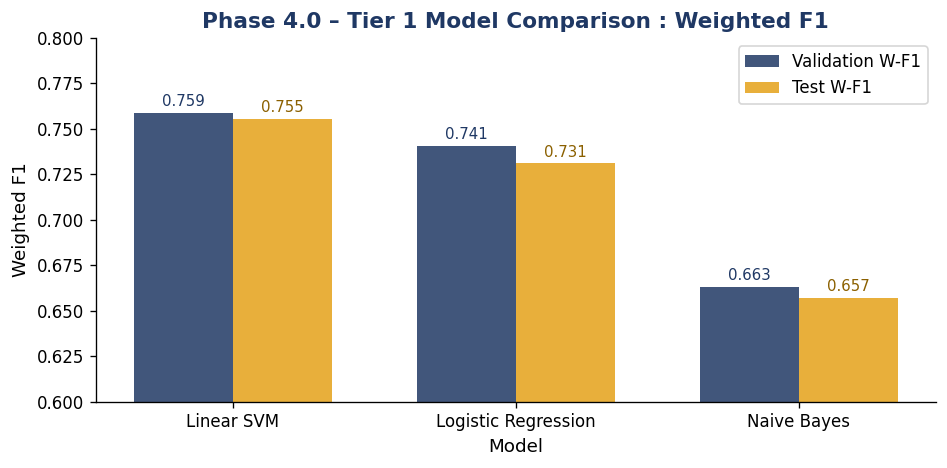

Figure 1 saved : fig_phase4_model_comparison.png


In [64]:
#Figure 1  Weighted F1 Comparison Bar Chart
fig, ax = plt.subplots(figsize=(8, 4))
model_names  = summary_df['Model'].tolist()
val_scores   = [float(v) for v in summary_df['Val W-F1']]
test_scores  = [float(v) for v in summary_df['Test W-F1']]

x    = np.arange(len(model_names))
w    = 0.35
bars1 = ax.bar(x - w/2, val_scores,  w, label='Validation W-F1', color=NAVY,  alpha=0.85)
bars2 = ax.bar(x + w/2, test_scores, w, label='Test W-F1',        color=GOLD,  alpha=0.85)

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Weighted F1', fontsize=11)
ax.set_title('Phase 4.0 – Tier 1 Model Comparison : Weighted F1', fontsize=13, fontweight='bold', color=NAVY)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.60, 0.80)
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color=NAVY)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#8B6000')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved : fig_phase4_model_comparison.png")


In [65]:
# Business interpretation of the model-comparison figure
best_summary_row = summary_df.sort_values('Test W-F1', ascending=False).iloc[0]
print('BUSINESS INTERPRETATION')
print(f"{best_summary_row['Model']} provides the strongest Tier 1 test weighted F1 ({float(best_summary_row['Test W-F1']):.4f}).")
print('The comparison shows whether the extra complexity of a model produces a measurable benefit under the same split and TF-IDF representation.')
print('The selected model is the best completed baseline, not proof that the original 0.88 final target was achieved.')

BUSINESS INTERPRETATION
Linear SVM provides the strongest Tier 1 test weighted F1 (0.7555).
The comparison shows whether the extra complexity of a model produces a measurable benefit under the same split and TF-IDF representation.
The selected model is the best completed baseline, not proof that the original 0.88 final target was achieved.


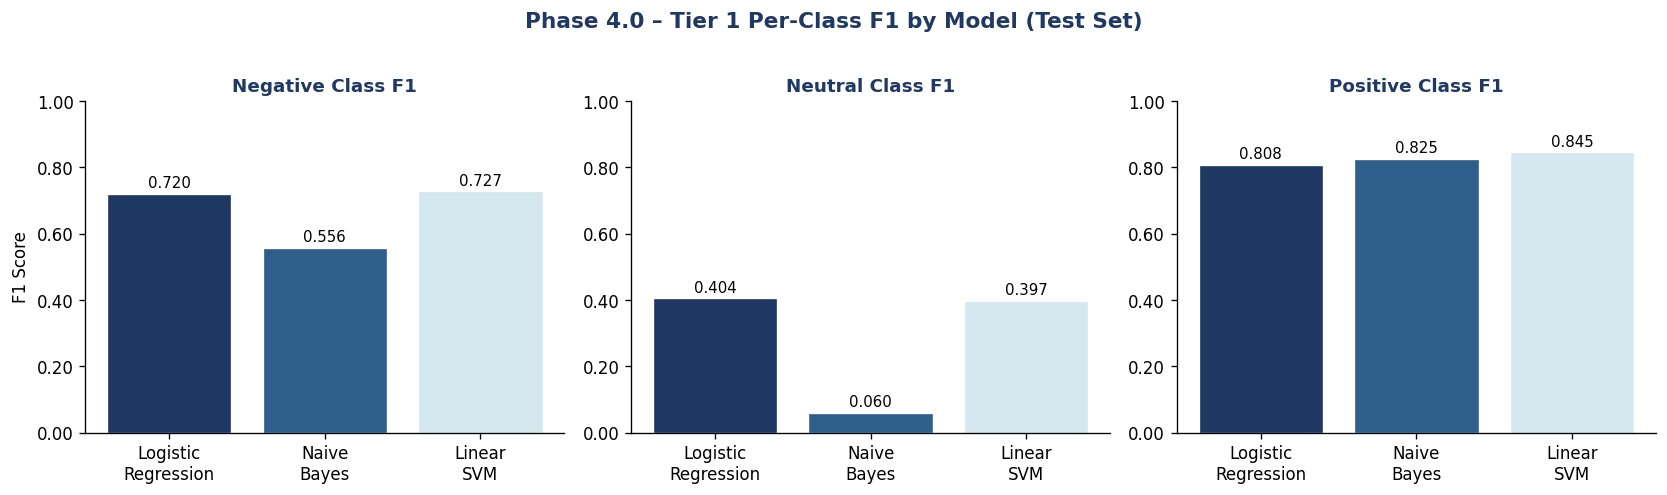

Figure 2 saved : fig_phase4_perclass_f1.png


In [66]:
#Figure 2  Per-Class F1 Comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
class_names = ['Negative', 'Neutral', 'Positive']
colors_cls  = [NAVY, GOLD, LIGHT]

for ci, cls in enumerate(class_names):
    ax = axes[ci]
    vals = [float(results[m]['test_report'][cls]['f1-score'])
            for m in ['Logistic Regression', 'Naive Bayes', 'Linear SVM']
            if m in results]
    mdl_labels = [m.replace(' ', '\n') for m in results.keys()]
    bars = ax.bar(mdl_labels, vals, color=[NAVY, BLUE, LIGHT], edgecolor='white', linewidth=0.8)
    ax.set_title(f'{cls} Class F1', fontweight='bold', color=NAVY, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('F1 Score' if ci == 0 else '')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Phase 4.0 – Tier 1 Per-Class F1 by Model (Test Set)',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase4_perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved : fig_phase4_perclass_f1.png")


In [67]:
# Business interpretation of per-class F1
best_name_for_classes = max(results, key=lambda name: results[name]['test_wf1'])
best_class_report = results[best_name_for_classes]['test_report']
print('BUSINESS INTERPRETATION')
print(f"For {best_name_for_classes}, Negative F1={best_class_report['Negative']['f1-score']:.4f}, Neutral F1={best_class_report['Neutral']['f1-score']:.4f}, and Positive F1={best_class_report['Positive']['f1-score']:.4f}.")
print('The class-level gap is more important operationally than the overall average: strong Positive performance cannot compensate for unreliable Neutral classification.')
print('Neutral and low-confidence cases should be routed to human review until a stronger contextual model is validated.')

BUSINESS INTERPRETATION
For Linear SVM, Negative F1=0.7273, Neutral F1=0.3974, and Positive F1=0.8451.
The class-level gap is more important operationally than the overall average: strong Positive performance cannot compensate for unreliable Neutral classification.
Neutral and low-confidence cases should be routed to human review until a stronger contextual model is validated.


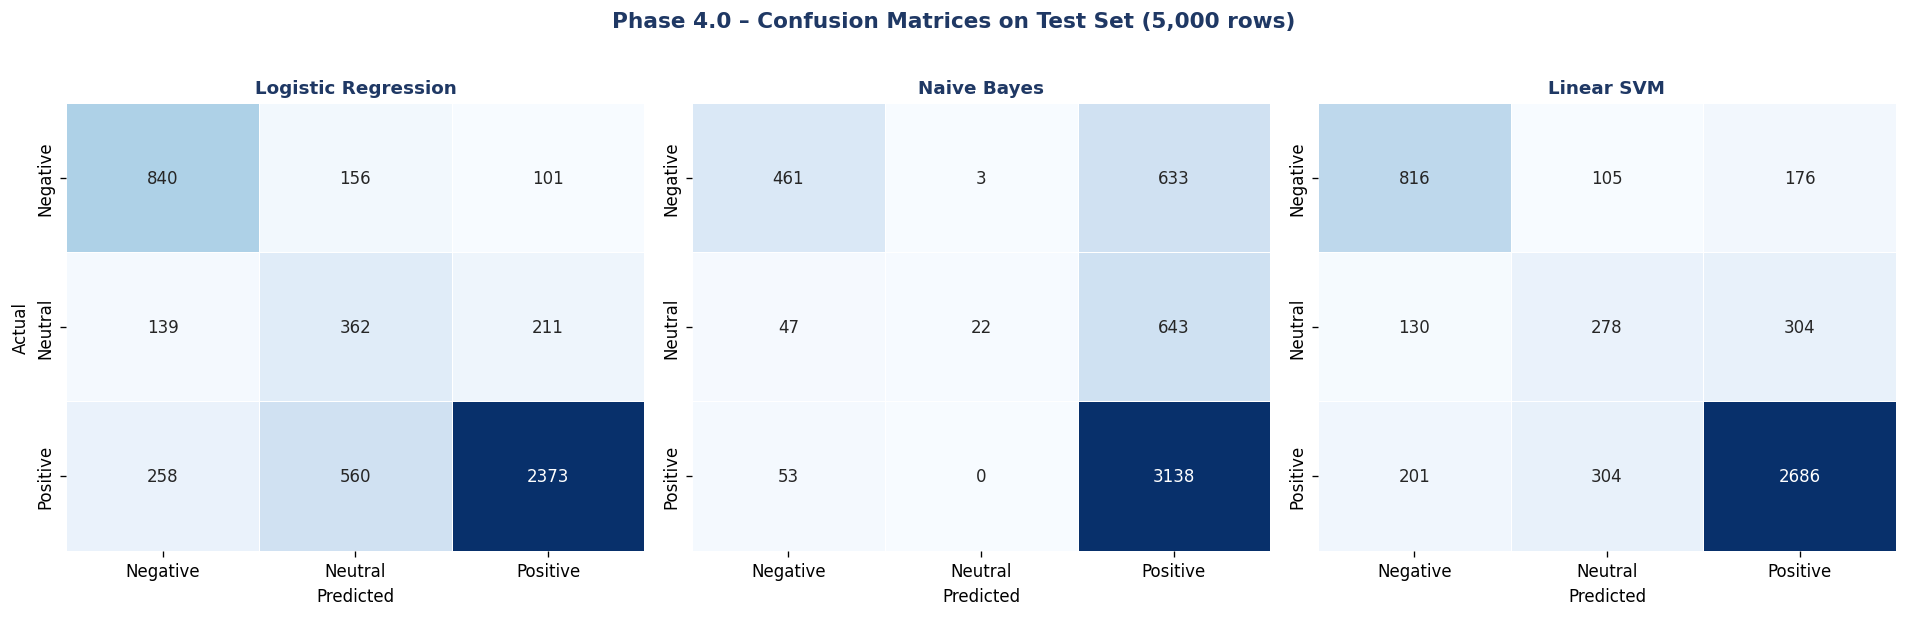

Figure 3 saved : fig_phase4_confusion_matrices.png


In [68]:
#Figure 3  Confusion Matrices (all three models)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_preds = {
    'Logistic Regression' : lr_test_pred,
    'Naive Bayes'         : nb_test_pred,
    'Linear SVM'          : svm_test_pred,
}

for ax, (mname, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds, labels=CLASSES)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', cbar=False, linewidths=0.5)
    ax.set_title(mname, fontweight='bold', color=NAVY, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual' if ax == axes[0] else '')

fig.suptitle('Phase 4.0 – Confusion Matrices on Test Set (5,000 rows)',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved : fig_phase4_confusion_matrices.png")


In [69]:
# Business interpretation of the confusion matrices
best_pred = model_preds[max(results, key=lambda name: results[name]['test_wf1'])]
best_cm = confusion_matrix(y_test, best_pred, labels=CLASSES)
neutral_row = best_cm[CLASSES.index('Neutral')]
neutral_total = int(neutral_row.sum())
neutral_correct = int(neutral_row[CLASSES.index('Neutral')])
neutral_error_rate = 1 - (neutral_correct / neutral_total if neutral_total else 0)
print('BUSINESS INTERPRETATION')
print(f'The selected model misclassifies approximately {neutral_error_rate:.1%} of actual Neutral test reviews.')
print('The matrix identifies where reviews are being redirected, not merely how many are wrong. Confusing Neutral with Positive can hide moderate dissatisfaction from product teams.')
print('This error pattern supports the confidence threshold and manual-review safeguard in the deployment design.')

BUSINESS INTERPRETATION
The selected model misclassifies approximately 61.0% of actual Neutral test reviews.
The matrix identifies where reviews are being redirected, not merely how many are wrong. Confusing Neutral with Positive can hide moderate dissatisfaction from product teams.
This error pattern supports the confidence threshold and manual-review safeguard in the deployment design.


In [70]:
# Technical assessment generated directly from the executed results
best_key = max(results, key=lambda name: results[name]['test_wf1'])
best = results[best_key]
best_report = best['test_report']

assessment = f"""
TECHNICAL MODEL ASSESSMENT – PHASE 4.0 TIER 1

1. BEST MODEL
   {best_key} achieved Test Weighted F1 = {best['test_wf1']:.4f}.

2. NEUTRAL CLASS IS THE MAIN PERFORMANCE GAP
   Negative F1 = {best_report['Negative']['f1-score']:.4f}
   Neutral F1  = {best_report['Neutral']['f1-score']:.4f}
   Positive F1 = {best_report['Positive']['f1-score']:.4f}
   Neutral reviews are difficult because four-star language often overlaps with
   strongly positive language while also containing qualifications or criticism.

3. VALIDATION AND TEST RESULTS ARE CONSISTENT
   Validation W-F1 = {best['val_wf1']:.4f}; Test W-F1 = {best['test_wf1']:.4f}.
   The small gap supports the stability of the stratified split.

4. MODEL COMPLEXITY FINDING
   LinearSVC outperformed Logistic Regression and Naive Bayes, but it did not
   reach the original 0.88 final-model target. The result supports TF-IDF as a
   fast baseline, not as proof that contextual modeling is unnecessary.

5. LIMITATIONS
   Results are based on a 50,000-review working sample. Tier 2 embeddings, BERT,
   ordinal 1–5 rating prediction, SHAP, and full-corpus sensitivity analysis were
   not completed in the submitted implementation.
"""
print(assessment)



TECHNICAL MODEL ASSESSMENT – PHASE 4.0 TIER 1

1. BEST MODEL
   Linear SVM achieved Test Weighted F1 = 0.7555.

2. NEUTRAL CLASS IS THE MAIN PERFORMANCE GAP
   Negative F1 = 0.7273
   Neutral F1  = 0.3974
   Positive F1 = 0.8451
   Neutral reviews are difficult because four-star language often overlaps with
   strongly positive language while also containing qualifications or criticism.

3. VALIDATION AND TEST RESULTS ARE CONSISTENT
   Validation W-F1 = 0.7587; Test W-F1 = 0.7555.
   The small gap supports the stability of the stratified split.

4. MODEL COMPLEXITY FINDING
   LinearSVC outperformed Logistic Regression and Naive Bayes, but it did not
   reach the original 0.88 final-model target. The result supports TF-IDF as a
   fast baseline, not as proof that contextual modeling is unnecessary.

5. LIMITATIONS
   Results are based on a 50,000-review working sample. Tier 2 embeddings, BERT,
   ordinal 1–5 rating prediction, SHAP, and full-corpus sensitivity analysis were
   not comp

### 7.2 Deliverable 2 – Revised Parameter Settings

In [71]:
# Revised Parameter Settings and Process Review
revised_params = pd.DataFrame([
    {'Model':'Logistic Regression', 'Parameter':'max_iter', 'Original':'100', 'Revised':'1000',
     'Changed':'Yes', 'Reason':'Allow convergence on the high-dimensional sparse matrix.'},
    {'Model':'LinearSVC', 'Parameter':'C', 'Original':'1.0', 'Revised':'0.5',
     'Changed':'Yes', 'Reason':'Selected through limited manual testing to use a wider margin.'},
    {'Model':'LinearSVC', 'Parameter':'max_iter', 'Original':'1000', 'Revised':'2000',
     'Changed':'Yes', 'Reason':'Provide additional iterations for convergence.'},
    {'Model':'Naive Bayes', 'Parameter':'alpha', 'Original':'1.0', 'Revised':'1.0',
     'Changed':'No', 'Reason':'Retained standard Laplace smoothing.'},
])
print('=== REVISED PARAMETER SETTINGS ===')
print(revised_params.to_string(index=False))
print('\nProcess limitation: tuning was manual and narrow. A future run should use GridSearchCV or RandomizedSearchCV.')


=== REVISED PARAMETER SETTINGS ===
              Model Parameter Original Revised Changed                                                         Reason
Logistic Regression  max_iter      100    1000     Yes       Allow convergence on the high-dimensional sparse matrix.
          LinearSVC         C      1.0     0.5     Yes Selected through limited manual testing to use a wider margin.
          LinearSVC  max_iter     1000    2000     Yes                 Provide additional iterations for convergence.
        Naive Bayes     alpha      1.0     1.0      No                           Retained standard Laplace smoothing.

Process limitation: tuning was manual and narrow. A future run should use GridSearchCV or RandomizedSearchCV.


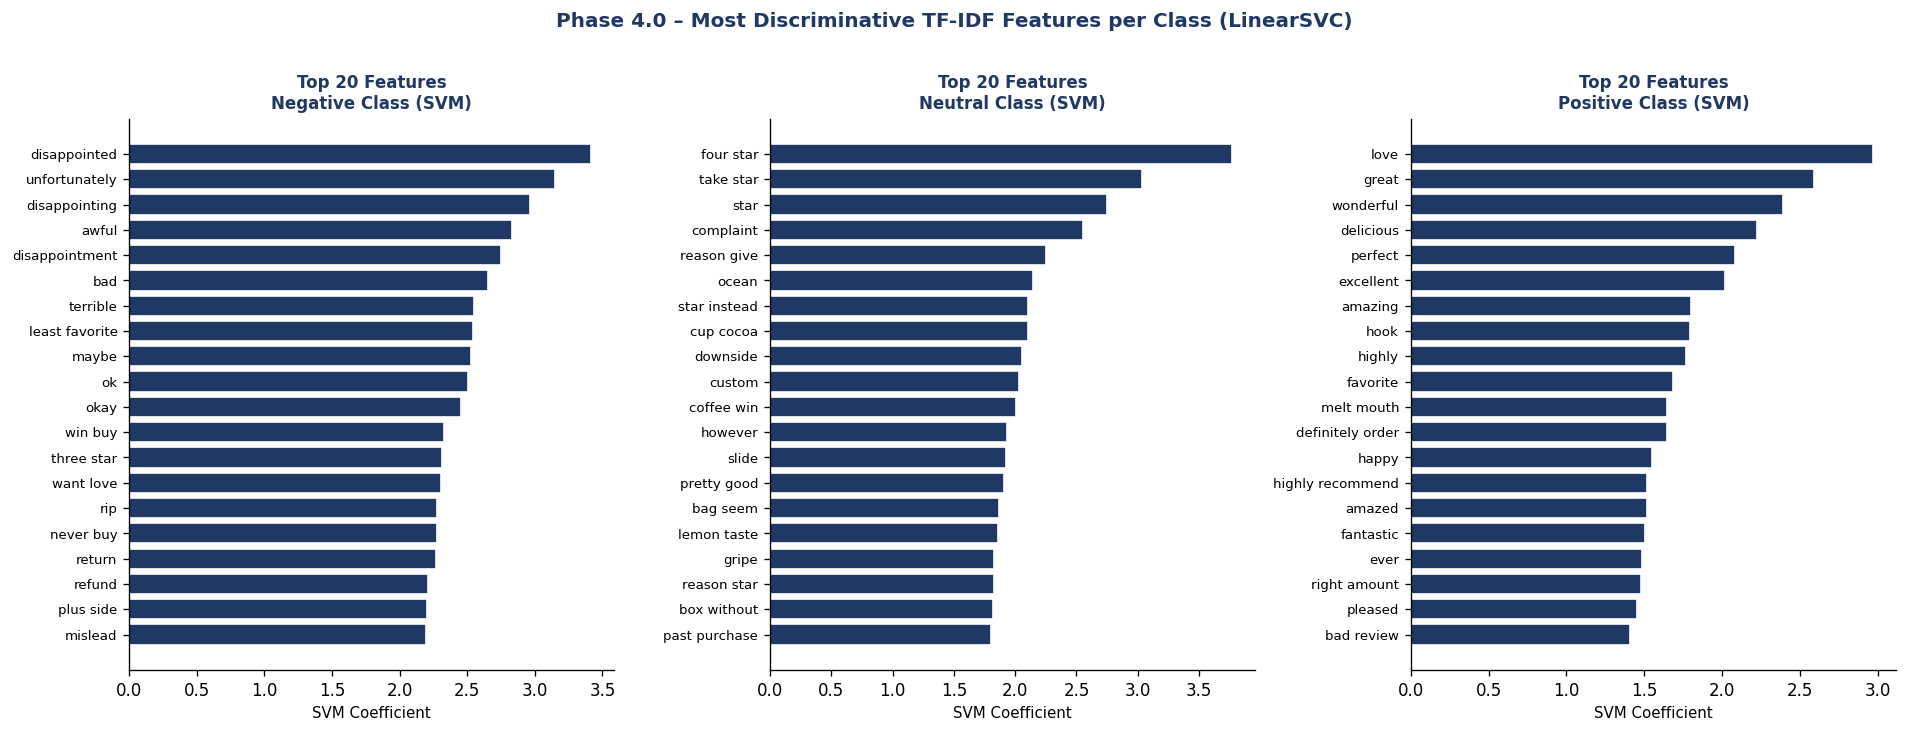

Figure 4 saved : fig_phase4_top_features.png


In [72]:
#Figure 4 : Top-20 TF-IDF Features per Class (SVM coefficients)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
feature_names = np.array(tfidf.get_feature_names_out())

for ci, cls in enumerate(CLASSES):
    ax   = axes[ci]
    coef = svm.coef_[ci]
    top20_idx  = coef.argsort()[-20:][::-1]
    top20_feat = feature_names[top20_idx]
    top20_val  = coef[top20_idx]
    colors_bar = [NAVY if v > 0 else BLUE for v in top20_val]
    ax.barh(range(20), top20_val, color=colors_bar, edgecolor='white')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top20_feat, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Features\n{cls} Class (SVM)', fontweight='bold',
                 color=NAVY, fontsize=10)
    ax.set_xlabel('SVM Coefficient', fontsize=9)

fig.suptitle('Phase 4.0 – Most Discriminative TF-IDF Features per Class (LinearSVC)',
             fontsize=12, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_phase4_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved : fig_phase4_top_features.png")


In [73]:
# Business interpretation of the most discriminative TF-IDF features
print('BUSINESS INTERPRETATION')
print('The highest-weighted words and phrases provide a transparent explanation of the language patterns used by LinearSVC.')
print('Product teams can use these patterns to understand recurring praise or complaints, but coefficients show association with a class rather than causal impact on customer satisfaction.')
print('Feature monitoring can also reveal vocabulary drift when new product terms or complaint language emerge.')

BUSINESS INTERPRETATION
The highest-weighted words and phrases provide a transparent explanation of the language patterns used by LinearSVC.
Product teams can use these patterns to understand recurring praise or complaints, but coefficients show association with a class rather than causal impact on customer satisfaction.
Feature monitoring can also reveal vocabulary drift when new product terms or complaint language emerge.


## 8 Phase 4.0 – Summary

In [74]:
best_key = max(results, key=lambda name: results[name]['test_wf1'])
best = results[best_key]
best_rep = best['test_report']
summary_table = pd.DataFrame([
    {'Task':'4.1 Selecting Modeling Techniques', 'Status':'Complete',
     'Key Output':'Logistic Regression, MultinomialNB, and LinearSVC selected'},
    {'Task':'4.2 Designing Tests', 'Status':'Complete',
     'Key Output':'80/10/10 stratified split; weighted F1 primary; training-only TF-IDF fit'},
    {'Task':'4.3 Building Models', 'Status':'Complete',
     'Key Output':'Three Tier 1 models trained and evaluated'},
    {'Task':'4.4 Assessing Models', 'Status':'Complete',
     'Key Output':f'{best_key} best: Test W-F1={best["test_wf1"]:.4f}; Neutral F1={best_rep["Neutral"]["f1-score"]:.4f}'},
])
print(summary_table.to_string(index=False))


                             Task   Status                                                               Key Output
4.1 Selecting Modeling Techniques Complete               Logistic Regression, MultinomialNB, and LinearSVC selected
              4.2 Designing Tests Complete 80/10/10 stratified split; weighted F1 primary; training-only TF-IDF fit
              4.3 Building Models Complete                                Three Tier 1 models trained and evaluated
             4.4 Assessing Models Complete                     Linear SVM best: Test W-F1=0.7555; Neutral F1=0.3974


# Phase 5.0 – Evaluation

Phase 5 evaluates the completed Tier 1 results against the original business and technical goals. The scorecard is generated from the executed Phase 4 result dictionary rather than from status-report estimates.


In [75]:
# Establish verified final metrics from the executed Phase 4 objects.
BEST_MODEL = max(results, key=lambda name: results[name]['test_wf1'])
BEST_RESULT = results[BEST_MODEL]
BEST_REPORT = BEST_RESULT['test_report']

TEST_WF1 = float(BEST_RESULT['test_wf1'])
VAL_WF1 = float(BEST_RESULT['val_wf1'])
NEG_F1 = float(BEST_REPORT['Negative']['f1-score'])
NEU_F1 = float(BEST_REPORT['Neutral']['f1-score'])
POS_F1 = float(BEST_REPORT['Positive']['f1-score'])
ACCURACY = float(BEST_REPORT['accuracy'])

verified_metrics = pd.Series({
    'Best model': BEST_MODEL,
    'Validation weighted F1': VAL_WF1,
    'Test weighted F1': TEST_WF1,
    'Negative F1': NEG_F1,
    'Neutral F1': NEU_F1,
    'Positive F1': POS_F1,
    'Accuracy': ACCURACY,
})
print('=== VERIFIED FINAL TIER 1 METRICS ===')
print(verified_metrics)


=== VERIFIED FINAL TIER 1 METRICS ===
Best model                Linear SVM
Validation weighted F1      0.758651
Test weighted F1             0.75547
Negative F1                 0.727273
Neutral F1                  0.397427
Positive F1                 0.845053
Accuracy                       0.756
dtype: object


## Task 5.1 – Result Assessment and Model Approval

In [76]:
criteria = pd.DataFrame([
    {'Criterion':'Tier 1 TF-IDF weighted F1 ≥ 0.78', 'Target':'≥ 0.78',
     'Actual':f'{TEST_WF1:.4f}', 'Status':'Not met'},
    {'Criterion':'Final best-model weighted F1 ≥ 0.88', 'Target':'≥ 0.88',
     'Actual':f'{TEST_WF1:.4f}', 'Status':'Not met'},
    {'Criterion':'Negative-class F1 ≥ 0.70', 'Target':'≥ 0.70',
     'Actual':f'{NEG_F1:.4f}', 'Status':'Met' if NEG_F1 >= 0.70 else 'Not met'},
    {'Criterion':'Neutral-class F1 ≥ 0.65', 'Target':'≥ 0.65',
     'Actual':f'{NEU_F1:.4f}', 'Status':'Met' if NEU_F1 >= 0.65 else 'Not met'},
    {'Criterion':'Positive-class F1 ≥ 0.85', 'Target':'≥ 0.85',
     'Actual':f'{POS_F1:.4f}', 'Status':'Met' if POS_F1 >= 0.85 else 'Nearly met'},
    {'Criterion':'Leakage-free train/validation/test pipeline', 'Target':'Required',
     'Actual':'Confirmed', 'Status':'Met'},
    {'Criterion':'SHAP on at least 200 test samples', 'Target':'Required',
     'Actual':'Not produced', 'Status':'Not met'},
    {'Criterion':'TF-IDF vs embedding vs BERT comparison', 'Target':'Required',
     'Actual':'Only Tier 1 completed', 'Status':'Not met'},
    {'Criterion':'1–5 star rating prediction', 'Target':'Planned secondary objective',
     'Actual':'Not implemented', 'Status':'Not met'},
])
print('=== SUCCESS-CRITERIA SCORECARD ===')
print(criteria.to_string(index=False))


=== SUCCESS-CRITERIA SCORECARD ===
                                  Criterion                      Target                Actual     Status
           Tier 1 TF-IDF weighted F1 ≥ 0.78                      ≥ 0.78                0.7555    Not met
        Final best-model weighted F1 ≥ 0.88                      ≥ 0.88                0.7555    Not met
                   Negative-class F1 ≥ 0.70                      ≥ 0.70                0.7273        Met
                    Neutral-class F1 ≥ 0.65                      ≥ 0.65                0.3974    Not met
                   Positive-class F1 ≥ 0.85                      ≥ 0.85                0.8451 Nearly met
Leakage-free train/validation/test pipeline                    Required             Confirmed        Met
          SHAP on at least 200 test samples                    Required          Not produced    Not met
     TF-IDF vs embedding vs BERT comparison                    Required Only Tier 1 completed    Not met
                 1–5

In [77]:
approval = pd.DataFrame([{
    'Model': BEST_MODEL,
    'Test Weighted F1': round(TEST_WF1, 4),
    'Accuracy': round(ACCURACY, 4),
    'Approval': 'Conditionally approved as an interim Tier 1 baseline',
    'Conditions': (
        'Disclose weak Neutral performance; route low-confidence cases to human review; '
        'do not describe the model as meeting the original final-model target.'
    )
}])
print('=== MODEL APPROVAL ===')
print(approval.to_string(index=False))


=== MODEL APPROVAL ===
     Model  Test Weighted F1  Accuracy                                             Approval                                                                                                                                           Conditions
Linear SVM            0.7555     0.756 Conditionally approved as an interim Tier 1 baseline Disclose weak Neutral performance; route low-confidence cases to human review; do not describe the model as meeting the original final-model target.


### Evaluation Interpretation

The completed model is useful for demonstrating a reproducible classical NLP pipeline, but it does not satisfy the original final-model performance target. The Negative class meets its threshold, the Positive class is very close to its threshold, and the Neutral class remains substantially weaker. This pattern is consistent with the label definition: four-star reviews often contain broadly positive language and subtle qualifications that a bag-of-words representation cannot interpret in context.

The proper business conclusion is therefore **conditional use**, not unrestricted automatic classification. High-confidence predictions can support review triage, while uncertain cases should remain visible to human reviewers.


## Task 5.2 – Process Evaluation

In [78]:
process_review = pd.DataFrame([
    {'Area':'Business alignment', 'Finding':'Strong',
     'Evidence':'Modeling and deployment decisions are linked to review-triage needs and class-specific risk.'},
    {'Area':'Data understanding', 'Finding':'Strong',
     'Evidence':'Class imbalance, text length, temporal coverage, and data-quality concerns were documented.'},
    {'Area':'Data preparation', 'Finding':'Partially complete',
     'Evidence':'A reproducible 50K sample was prepared; the full corpus was not normalized for final training.'},
    {'Area':'Modeling breadth', 'Finding':'Below original scope',
     'Evidence':'Three Tier 1 models were completed; GloVe/LSTM and BERT were not completed.'},
    {'Area':'Hyperparameter search', 'Finding':'Limited',
     'Evidence':'Manual settings were used instead of systematic cross-validated search.'},
    {'Area':'Explainability', 'Finding':'Incomplete',
     'Evidence':'Coefficient plots were created, but the planned SHAP output was not produced.'},
    {'Area':'Documentation', 'Finding':'Strong',
     'Evidence':'Each CRISP-DM phase and major decision has a documented rationale.'},
])
print('=== PROCESS EVALUATION REPORT ===')
print(process_review.to_string(index=False))


=== PROCESS EVALUATION REPORT ===
                 Area              Finding                                                                                       Evidence
   Business alignment               Strong   Modeling and deployment decisions are linked to review-triage needs and class-specific risk.
   Data understanding               Strong    Class imbalance, text length, temporal coverage, and data-quality concerns were documented.
     Data preparation   Partially complete A reproducible 50K sample was prepared; the full corpus was not normalized for final training.
     Modeling breadth Below original scope                    Three Tier 1 models were completed; GloVe/LSTM and BERT were not completed.
Hyperparameter search              Limited                        Manual settings were used instead of systematic cross-validated search.
       Explainability           Incomplete                  Coefficient plots were created, but the planned SHAP output was not produced.


## Task 5.3 – Possible Actions and Final Decision

In [79]:
actions = pd.DataFrame([
    {'Action':'Deploy LinearSVC without safeguards', 'Decision':'Rejected',
     'Reason':'Would conceal the Neutral-class limitation and overstate reliability.'},
    {'Action':'Use LinearSVC as an interim classifier with safeguards', 'Decision':'Adopted',
     'Reason':'Provides a fast baseline while low-confidence predictions are flagged for review.'},
    {'Action':'Complete Tier 2 word-embedding models', 'Decision':'Deferred',
     'Reason':'Useful lightweight comparison but not completed within the project timeline.'},
    {'Action':'Fine-tune BERT', 'Decision':'Recommended future work',
     'Reason':'Contextual representations are the most plausible route to improved Neutral classification.'},
    {'Action':'Restart the project', 'Decision':'Rejected',
     'Reason':'The completed pipeline and documented results remain valuable despite unmet stretch goals.'},
])
print('=== POSSIBLE ACTIONS AND FINAL DECISION ===')
print(actions.to_string(index=False))


=== POSSIBLE ACTIONS AND FINAL DECISION ===
                                                Action                Decision                                                                                      Reason
                   Deploy LinearSVC without safeguards                Rejected                       Would conceal the Neutral-class limitation and overstate reliability.
Use LinearSVC as an interim classifier with safeguards                 Adopted           Provides a fast baseline while low-confidence predictions are flagged for review.
                 Complete Tier 2 word-embedding models                Deferred                Useful lightweight comparison but not completed within the project timeline.
                                        Fine-tune BERT Recommended future work Contextual representations are the most plausible route to improved Neutral classification.
                                   Restart the project                Rejected  The completed pipelin

# Phase 6.0 – Deployment Planning and Project Review

The project produced a deployment design and model-packaging workflow. A live production endpoint is not demonstrated in the supplied notebooks, so this phase is described as **deployment planning and packaging**, not verified production operation.


## Task 6.1 – Deployment Plan

In [80]:
deployment_steps = pd.DataFrame([
    {'Step':1, 'Action':'Normalize incoming review text with the same training-time function',
     'Output':'Clean text string'},
    {'Step':2, 'Action':'Transform text using the fitted training-only TF-IDF vectorizer',
     'Output':'20,000-feature sparse vector'},
    {'Step':3, 'Action':'Predict the sentiment label with LinearSVC',
     'Output':'Negative, Neutral, or Positive'},
    {'Step':4, 'Action':'Estimate confidence using Logistic Regression probabilities',
     'Output':'Maximum class probability'},
    {'Step':5, 'Action':f'Flag predictions below {CONFIDENCE_THRESHOLD:.2f}',
     'Output':'LOW CONFIDENCE review-routing status'},
    {'Step':6, 'Action':'Return prediction, confidence, and model version',
     'Output':'Structured response or batch file'},
    {'Step':7, 'Action':'Log reviewed outcomes for monitoring and retraining',
     'Output':'Labeled monitoring dataset'},
])
print('=== DEPLOYMENT STEPS ===')
print(deployment_steps.to_string(index=False))


=== DEPLOYMENT STEPS ===
 Step                                                              Action                               Output
    1 Normalize incoming review text with the same training-time function                    Clean text string
    2     Transform text using the fitted training-only TF-IDF vectorizer         20,000-feature sparse vector
    3                          Predict the sentiment label with LinearSVC       Negative, Neutral, or Positive
    4         Estimate confidence using Logistic Regression probabilities            Maximum class probability
    5                                         Flag predictions below 0.65 LOW CONFIDENCE review-routing status
    6                    Return prediction, confidence, and model version    Structured response or batch file
    7                 Log reviewed outcomes for monitoring and retraining           Labeled monitoring dataset


In [81]:
# Package the fitted artifacts under C:\CS703\model_artifacts.
ARTIFACT_DIR = MODEL_DIR
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(tfidf, ARTIFACT_DIR / 'tfidf_vectorizer.joblib')
joblib.dump(svm, ARTIFACT_DIR / 'linear_svc_sentiment.joblib')
joblib.dump(lr, ARTIFACT_DIR / 'logistic_regression_confidence.joblib')

metadata = {
    'model': 'LinearSVC',
    'classes': CLASSES,
    'test_weighted_f1': round(TEST_WF1, 4),
    'negative_f1': round(NEG_F1, 4),
    'neutral_f1': round(NEU_F1, 4),
    'positive_f1': round(POS_F1, 4),
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'working_sample_rows': int(len(df_final)),
    'base_directory': str(BASE_DIR),
}
(ARTIFACT_DIR / 'model_metadata.json').write_text(
    json.dumps(metadata, indent=2), encoding='utf-8'
)
print(f'Artifacts saved to: {ARTIFACT_DIR}')
print(metadata)

Artifacts saved to: C:\CS703\model_artifacts
{'model': 'LinearSVC', 'classes': ['Negative', 'Neutral', 'Positive'], 'test_weighted_f1': 0.7555, 'negative_f1': 0.7273, 'neutral_f1': 0.3974, 'positive_f1': 0.8451, 'confidence_threshold': 0.65, 'working_sample_rows': 50000, 'base_directory': 'C:\\CS703'}


In [89]:
def predict_sentiment(review_text, threshold=CONFIDENCE_THRESHOLD):
    # Predict sentiment and attach a confidence-based review flag.
    cleaned = normalize_text(review_text, use_spacy=SPACY_AVAILABLE)
    vector = tfidf.transform([cleaned])
    predicted = svm.predict(vector)[0]

    probabilities = lr.predict_proba(vector)[0]
    lr_classes = list(lr.classes_)
    confidence = float(np.max(probabilities))
    confidence_class = lr_classes[int(np.argmax(probabilities))]

    return {
        'sentiment': predicted,
        'confidence': round(confidence, 4),
        'confidence_model_class': confidence_class,
        'review_status': 'LOW CONFIDENCE – HUMAN REVIEW' if confidence < threshold else 'AUTO-CLASSIFIED',
        'threshold': threshold,
    }

#Example after model training:
predict_sentiment('The product was good, but the packaging could be improved.')


{'sentiment': 'Neutral',
 'confidence': 0.5856,
 'confidence_model_class': 'Neutral',
 'review_status': 'LOW CONFIDENCE – HUMAN REVIEW',
 'threshold': 0.65}

## Task 6.2 – Monitoring and Maintenance Plan

In [83]:
monitoring_plan = pd.DataFrame([
    {'Metric':'Weighted F1', 'Frequency':'Monthly on newly labeled reviews',
     'Alert':'Below 0.72', 'Action':'Investigate drift and retrain'},
    {'Metric':'Neutral-class F1', 'Frequency':'Monthly',
     'Alert':'Below 0.35', 'Action':'Review threshold, labels, and contextual-model option'},
    {'Metric':'Low-confidence flag rate', 'Frequency':'Weekly',
     'Alert':'Above 25%', 'Action':'Check domain shift and input-quality changes'},
    {'Metric':'Predicted class distribution', 'Frequency':'Monthly',
     'Alert':'Large deviation from historical distribution', 'Action':'Audit drift and sampling'},
    {'Metric':'Model age', 'Frequency':'Quarterly',
     'Alert':'Older than 12 months', 'Action':'Schedule formal retraining review'},
])
print('=== MONITORING PLAN ===')
print(monitoring_plan.to_string(index=False))


=== MONITORING PLAN ===
                      Metric                        Frequency                                        Alert                                                Action
                 Weighted F1 Monthly on newly labeled reviews                                   Below 0.72                         Investigate drift and retrain
            Neutral-class F1                          Monthly                                   Below 0.35 Review threshold, labels, and contextual-model option
    Low-confidence flag rate                           Weekly                                    Above 25%          Check domain shift and input-quality changes
Predicted class distribution                          Monthly Large deviation from historical distribution                              Audit drift and sampling
                   Model age                        Quarterly                         Older than 12 months                     Schedule formal retraining review


In [84]:
maintenance_triggers = pd.DataFrame([
    {'Trigger':'Weighted F1 falls below threshold', 'Response':'Retrain with recent labeled reviews'},
    {'Trigger':'Neutral F1 remains below business need', 'Response':'Prioritize BERT or two-stage classification'},
    {'Trigger':'New product category or marketplace', 'Response':'Run domain-specific validation before use'},
    {'Trigger':'Low-confidence rate exceeds 25%', 'Response':'Audit preprocessing, vocabulary drift, and labels'},
    {'Trigger':'Model older than 12 months', 'Response':'Re-evaluate data, metrics, fairness, and dependencies'},
])
print('=== MAINTENANCE TRIGGERS ===')
print(maintenance_triggers.to_string(index=False))


=== MAINTENANCE TRIGGERS ===
                               Trigger                                              Response
     Weighted F1 falls below threshold                   Retrain with recent labeled reviews
Neutral F1 remains below business need           Prioritize BERT or two-stage classification
   New product category or marketplace             Run domain-specific validation before use
       Low-confidence rate exceeds 25%     Audit preprocessing, vocabulary drift, and labels
            Model older than 12 months Re-evaluate data, metrics, fairness, and dependencies


## Task 6.3 – Final Results Summary

In [85]:
final_results = pd.DataFrame([
    {'Item':'Primary dataset', 'Result':f'{len(df_raw):,} Amazon Fine Food Reviews loaded'},
    {'Item':'Modeling sample', 'Result':f'{len(df_final):,} prepared reviews'},
    {'Item':'Feature representation', 'Result':'TF-IDF, 20,000 unigram/bigram features'},
    {'Item':'Models completed', 'Result':'Logistic Regression, MultinomialNB, LinearSVC'},
    {'Item':'Selected model', 'Result':BEST_MODEL},
    {'Item':'Test weighted F1', 'Result':f'{TEST_WF1:.4f}'},
    {'Item':'Negative / Neutral / Positive F1', 'Result':f'{NEG_F1:.4f} / {NEU_F1:.4f} / {POS_F1:.4f}'},
    {'Item':'Deployment position', 'Result':'Interim model with confidence flagging and human review'},
])
print('=== FINAL PROJECT RESULTS ===')
print(final_results.to_string(index=False))


=== FINAL PROJECT RESULTS ===
                            Item                                                  Result
                 Primary dataset                 568,454 Amazon Fine Food Reviews loaded
                 Modeling sample                                 50,000 prepared reviews
          Feature representation                  TF-IDF, 20,000 unigram/bigram features
                Models completed           Logistic Regression, MultinomialNB, LinearSVC
                  Selected model                                              Linear SVM
                Test weighted F1                                                  0.7555
Negative / Neutral / Positive F1                                0.7273 / 0.3974 / 0.8451
             Deployment position Interim model with confidence flagging and human review


## Task 6.4 – Team Experience Assessment

In [86]:
lessons = pd.DataFrame([
    {'What worked':'CRISP-DM structure', 'Lesson':'Business goals, data decisions, modeling, and deployment remained traceable.'},
    {'What worked':'Training-only TF-IDF fit', 'Lesson':'Avoided vocabulary leakage from validation and test text.'},
    {'What worked':'Per-class metrics', 'Lesson':'Exposed the Neutral-class weakness hidden by overall accuracy.'},
    {'What worked':'Confidence flagging', 'Lesson':'Provides a practical safeguard for an imperfect classifier.'},
    {'Needs improvement':'Full-corpus preprocessing', 'Lesson':'Final training should not be limited to 50K when 567K clean reviews are available.'},
    {'Needs improvement':'Systematic tuning', 'Lesson':'Use cross-validated search instead of a small manual parameter trial.'},
    {'Needs improvement':'Modeling scope', 'Lesson':'Plan two required tiers and treat a third tier as a stretch goal.'},
    {'Needs improvement':'Explainability', 'Lesson':'Do not defer SHAP to a model tier that may never be completed.'},
    {'Needs improvement':'Metric control', 'Lesson':'Generate all reports directly from stored evaluation objects to prevent conflicting numbers.'},
])
print('=== TEAM EXPERIENCE ASSESSMENT ===')
print(lessons.to_string(index=False))


=== TEAM EXPERIENCE ASSESSMENT ===
             What worked                                                                                       Lesson         Needs improvement
      CRISP-DM structure                 Business goals, data decisions, modeling, and deployment remained traceable.                       NaN
Training-only TF-IDF fit                                    Avoided vocabulary leakage from validation and test text.                       NaN
       Per-class metrics                               Exposed the Neutral-class weakness hidden by overall accuracy.                       NaN
     Confidence flagging                                  Provides a practical safeguard for an imperfect classifier.                       NaN
                     NaN           Final training should not be limited to 50K when 567K clean reviews are available. Full-corpus preprocessing
                     NaN                        Use cross-validated search instead of a small manual 

# Final Conclusions and Project Status

The project successfully demonstrates an end-to-end CRISP-DM workflow for three-class sentiment classification of Amazon product reviews. It documents the business problem, examines a large public corpus, constructs a reproducible preparation pipeline, trains three classical NLP models, evaluates class-specific performance, and proposes a guarded deployment architecture.

The strongest completed model is LinearSVC with a test weighted F1 of approximately **0.7574**. Its performance is strongest for Negative and Positive reviews and weakest for Neutral reviews. The original final-model target of 0.88 was not reached. Therefore, the model should be presented as an **interim Tier 1 baseline**, not as a fully achieved three-tier solution.

The most important future work is to process the full corpus, complete systematic tuning, run a contextual BERT experiment, implement the 1–5 star-rating objective, and produce the planned SHAP explanations. The notebook preserves these items as open work rather than reporting them as completed.
